## Workspace setup

In [1]:
from datetime import datetime  
import uproot
from functools import partial
import numpy as np
import tensorflow as tf
import importlib

2023-05-30 14:37:02.868619: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Training dataset preparation

2023-05-30 14:44:56.779978: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2023-05-30 14:44:58.502250: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


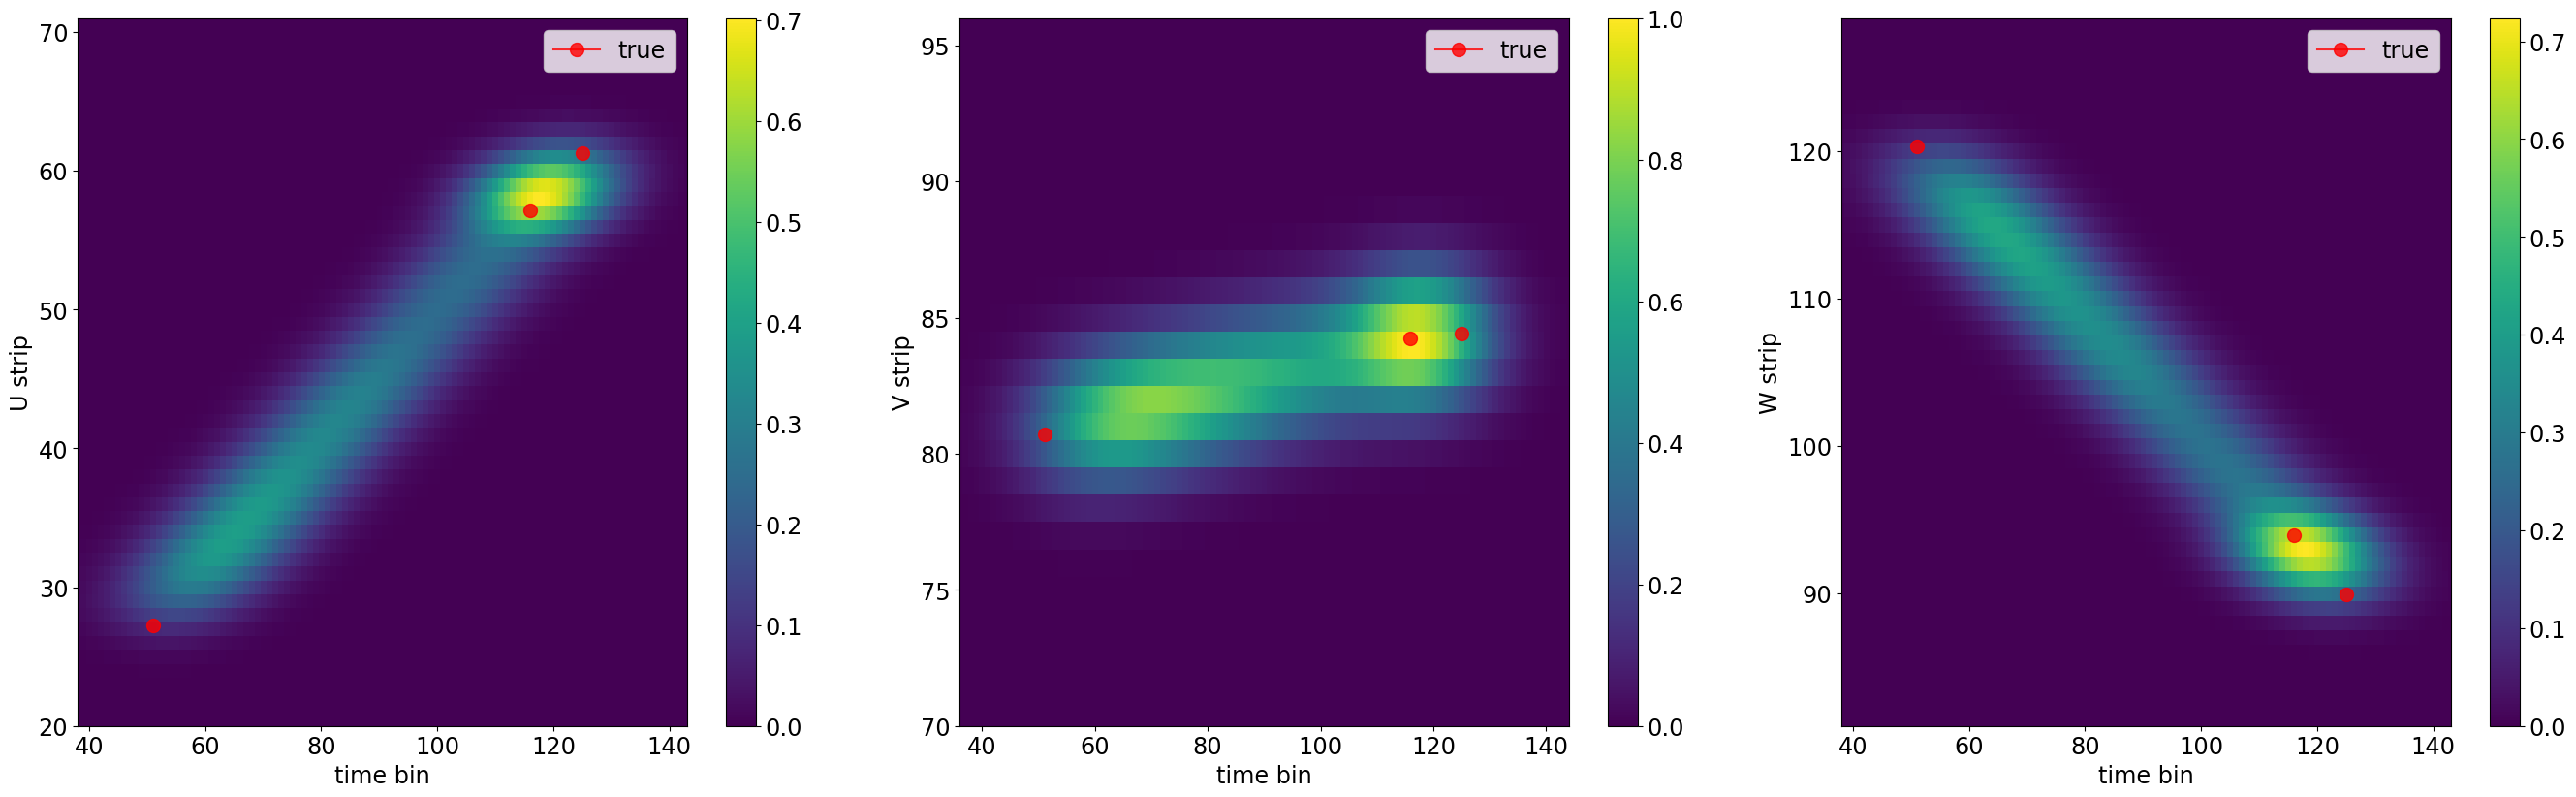

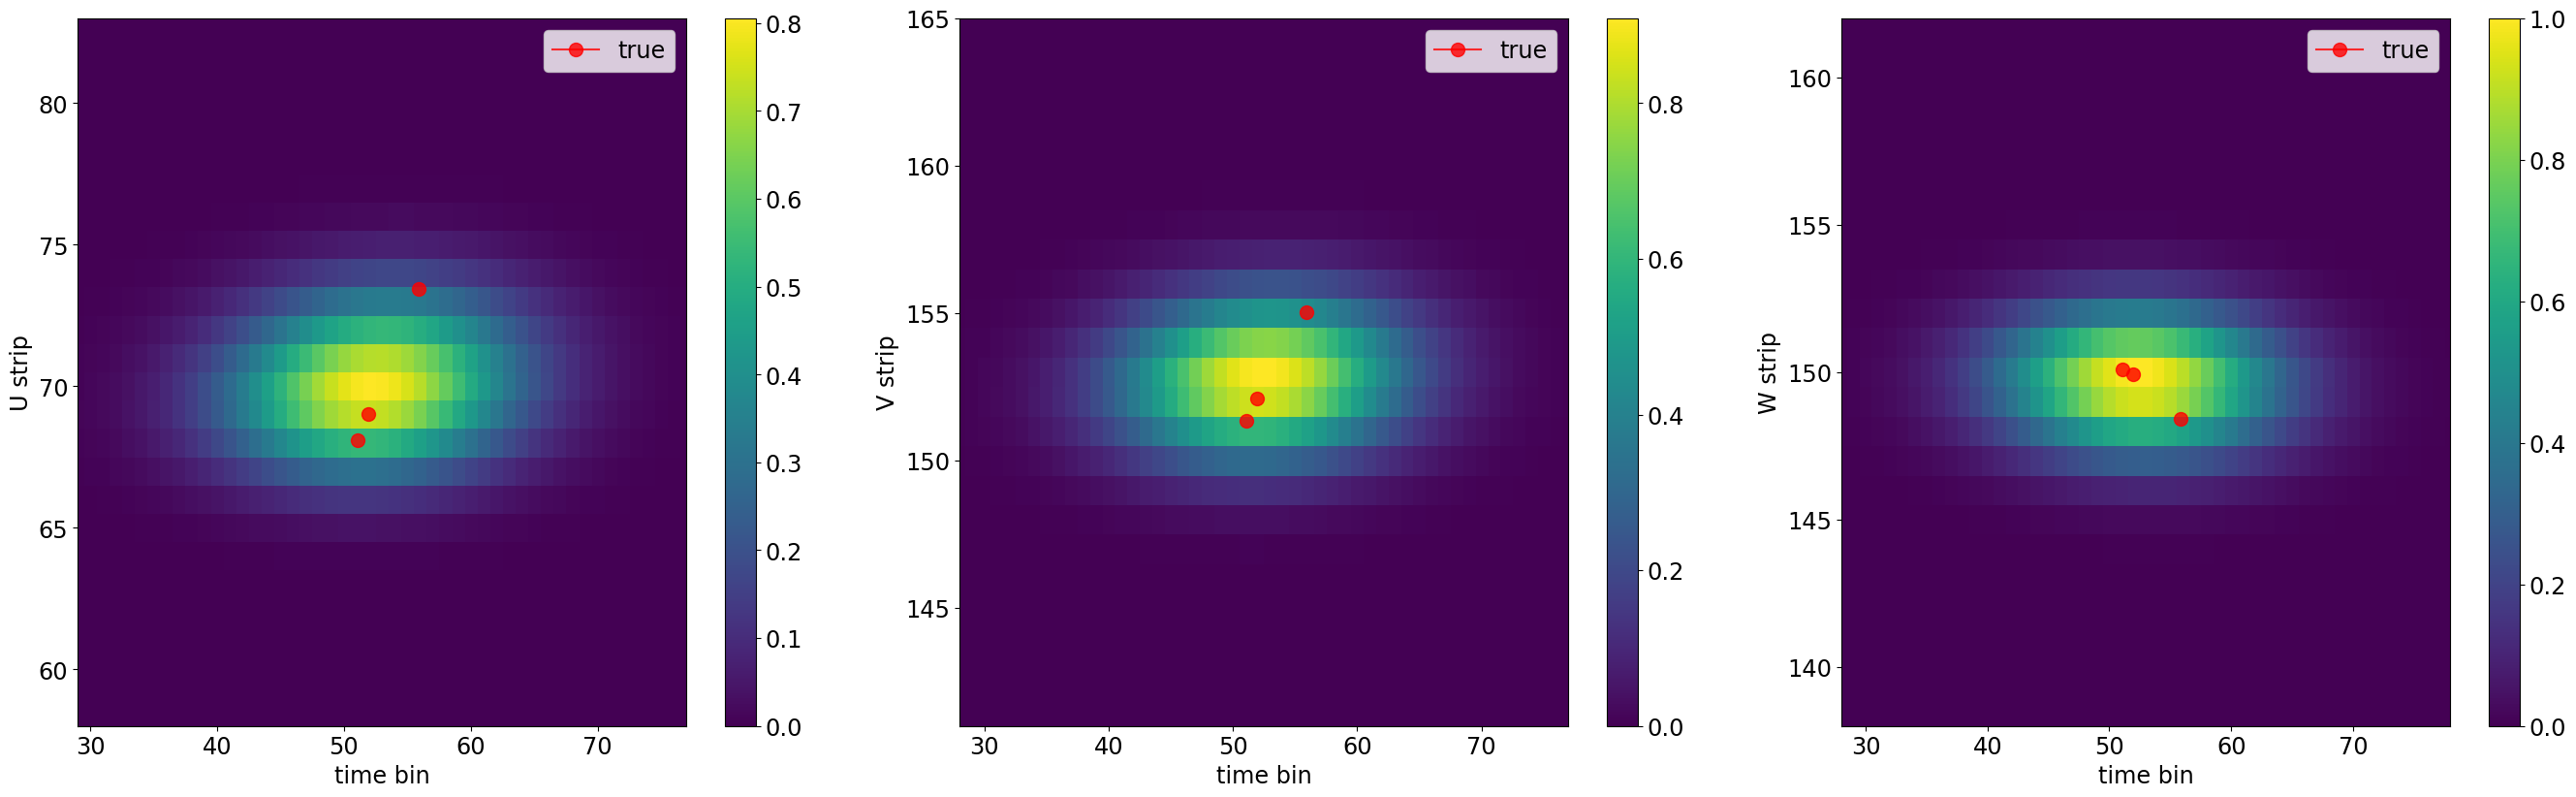

In [4]:
import io_functions as io
importlib.reload(io)

import plotting_functions as plf
importlib.reload(plf)

batchSize = 20
train_files = ['data/E_11_sigma_2/out_C_arr_1.root:TPCData',
               'data/E_11_sigma_2/out_C_arr_2.root:TPCData', 
               'data/E_11_sigma_2/out_C_arr_3.root:TPCData', 
               'data/E_11_sigma_2/out_C_arr_4.root:TPCData',
               'data/E_11_sigma_2/out_C_arr_5.root:TPCData',
               'data/E_11_sigma_2/out_C_arr_6.root:TPCData',
               'data/E_11_sigma_2/out_C_arr_7.root:TPCData',
              ]
datasetGenerator = partial(io.generator, files=train_files, batchSize=batchSize)

train_dataset = tf.data.Dataset.from_generator(
     datasetGenerator,
     output_signature=(
         tf.TensorSpec(shape=(batchSize,) + (io.projections.shape), dtype=tf.float32),
         tf.TensorSpec(shape=(batchSize,9), dtype=tf.float32)))

for aBatch in train_dataset.take(1):
    plf.plotEvent(aBatch, model=None)
    pass

test_files = ['data/E_11_sigma_2/out_C_arr_8.root:TPCData']
datasetGenerator = partial(io.generator, files=test_files, batchSize=batchSize)

test_dataset = tf.data.Dataset.from_generator(
     datasetGenerator,
     output_signature=(
         tf.TensorSpec(shape=(batchSize,) + (io.projections.shape), dtype=tf.float32),
         tf.TensorSpec(shape=(batchSize,9), dtype=tf.float32)))
 
for aBatch in test_dataset.take(1):
    plf.plotEvent(aBatch, model=None)
    pass

## Model definition

In [6]:
model = tf.keras.Sequential([
  tf.keras.layers.Resizing(height=128, width=128), 
  tf.keras.layers.Conv2D(16, 5, padding='same', activation='relu', 
                         data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 5, padding='same', activation='relu', 
                         data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 5, padding='same', activation='relu', 
                         data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(128, activation='relu'), 
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(9)
])

initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                decay_steps=5000,
                decay_rate=0.98,
                staircase=False)

optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr_schedule) 
model.compile(optimizer = optimizer, 
              loss = 'mse', 
              metrics=['mse']) 

## Model training

2023-05-30 18:58:23.257273: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-05-30 18:58:23.257309: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2023-05-30 18:58:23.380003: I tensorflow/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2023-05-30 18:58:23.382160: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1813] CUPTI activity buffer flushed


Epoch 1/50
      9/Unknown - 3s 303ms/step - loss: 1.8605e-04 - mse: 1.8605e-04

2023-05-30 18:58:26.306431: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-05-30 18:58:26.306506: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


     20/Unknown - 6s 318ms/step - loss: 1.8375e-04 - mse: 1.8375e-04

2023-05-30 18:58:29.873214: I tensorflow/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2023-05-30 18:58:29.874405: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1813] CUPTI activity buffer flushed
2023-05-30 18:58:29.901688: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_collector.cc:541]  GpuTracer has collected 1757 callback api events and 1736 activity events. 
2023-05-30 18:58:29.911790: I tensorflow/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.


...

INFO:tensorflow:Unsupported signature for serialization: ((TensorSpec(shape=(9,), dtype=tf.float32, name='gradient'), <tensorflow.python.framework.func_graph.UnknownArgument object at 0x7f3fcd093a00>, 139912049131072), {}).


INFO:tensorflow:Unsupported signature for serialization: ((TensorSpec(shape=(9,), dtype=tf.float32, name='gradient'), <tensorflow.python.framework.func_graph.UnknownArgument object at 0x7f3fcd093a00>, 139912049131072), {}).


INFO:tensorflow:Assets written to: training/{epochs:04d}_2023_May_31_08_11_32/assets


INFO:tensorflow:Assets written to: training/{epochs:04d}_2023_May_31_08_11_32/assets


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing_1 (Resizing)       (None, 128, 128, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 128, 128, 16)      1216      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 64, 64, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 64, 64, 32)        12832     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 32, 32, 64)       

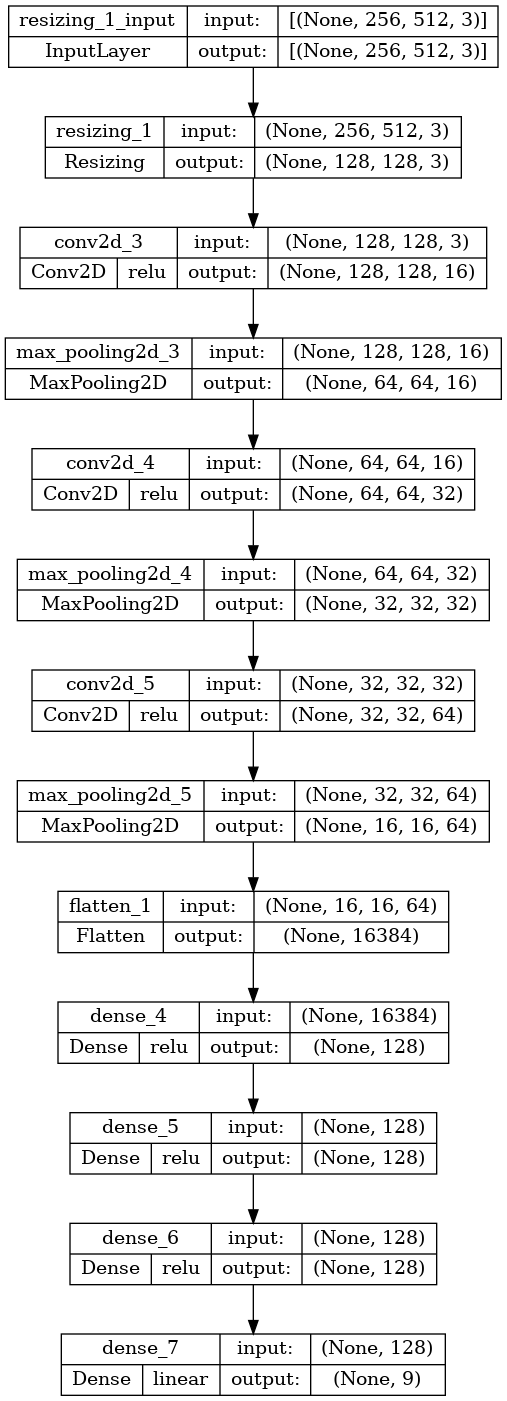

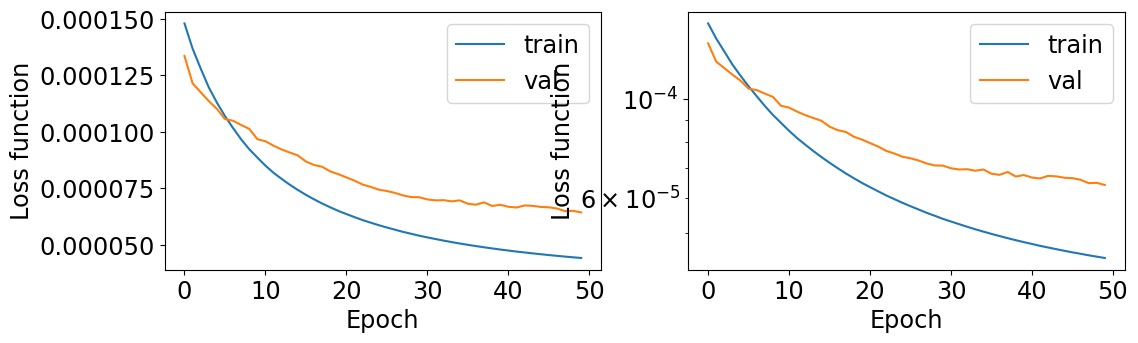

In [40]:
%%time

import plotting_functions as plf
importlib.reload(plf)

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, profile_batch=(10, 20))
early_stop_callback = tf.keras.callbacks.EarlyStopping(patience=5, verbose=1)
callbacks =  [tensorboard_callback]

epochs=50
history = model.fit(train_dataset, 
                    epochs=epochs,
                    verbose = 1,
                    workers = 3,
                    use_multiprocessing = True,
                    validation_data = test_dataset.take(10),
                    callbacks=callbacks
                    )
plf.plotTrainHistory(history)

current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
print("Training start. Current Time =", current_time)

job_dir = "training/{epochs:04d}_"+current_time
model.save(job_dir, save_format='tf')

model.summary()
tf.keras.utils.plot_model(
    model, to_file="fig_png/model.png",
    show_shapes=True, show_dtype=False, show_layer_names=True,
    rankdir="TB", expand_nested=False,
    dpi=96, layer_range=None,
    show_layer_activations=True, show_trainable=False)

## Model performance on training data.

Fill Pandas DataFrame with true and response values.

2023-05-31 08:55:08.447273: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


CPU times: user 2min 20s, sys: 23.4 s, total: 2min 43s
Wall time: 2min 28s


,GEN_StartPosX,GEN_StartPosY,GEN_StartPosZ,GEN_StopPosX_Part1,GEN_StopPosY_Part1,GEN_StopPosZ_Part1,GEN_StopPosX_Part2,GEN_StopPosY_Part2,GEN_StopPosZ_Part2,RECO_StartPosX,RECO_StartPosY,RECO_StartPosZ,RECO_StopPosX_Part1,RECO_StopPosY_Part1,RECO_StopPosZ_Part1,RECO_StopPosX_Part2,RECO_StopPosY_Part2,RECO_StopPosZ_Part2
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.280925,-0.138562,-52.240620,-1.152404,0.038356,-52.127464,-0.198385,-0.169770,-52.266186,0.357529,-0.224378,-52.216366,-1.132452,0.049126,-52.176434,-0.135439,-0.299910,-52.249233
std,57.539192,10.009161,18.580299,69.224594,35.699589,22.947239,57.748417,10.907412,21.910357,57.531540,9.980319,18.558477,69.214577,35.775822,22.896049,57.713322,10.861494,21.896738
min,-99.999596,-19.960903,-66.385445,-270.401794,-184.575974,-165.113373,-109.818939,-30.528181,-66.387596,-106.213440,-20.843925,-67.530273,-249.670700,-166.516190,-160.752350,-108.892403,-28.607782,-70.462654
25%,-49.474999,-8.259488,-63.703587,-52.709280,-20.860404,-66.387596,-49.782126,-8.514816,-66.387596,-49.299717,-8.302088,-63.651152,-52.839921,-20.730596,-66.396797,-49.767708,-8.593467,-66.389757
50%,0.856568,-0.213262,-60.476513,-0.767246,0.229270,-66.297386,0.650727,-0.195302,-66.387596,1.065143,-0.247739,-60.475843,-0.704252,0.292522,-65.608143,0.638556,-0.396654,-65.745800
75%,49.682680,7.941508,-47.720428,50.774866,20.947572,-43.314122,49.059068,8.205561,-44.454586,49.779449,7.776788,-47.706825,50.645851,21.096480,-43.375257,49.172419,8.042438,-44.373801
max,99.948830,19.981714,50.313652,235.536667,230.612488,173.792557,109.783302,31.058699,61.529034,102.333832,23.711746,51.645916,225.812027,188.975571,152.832062,108.926949,29.002880,62.084557


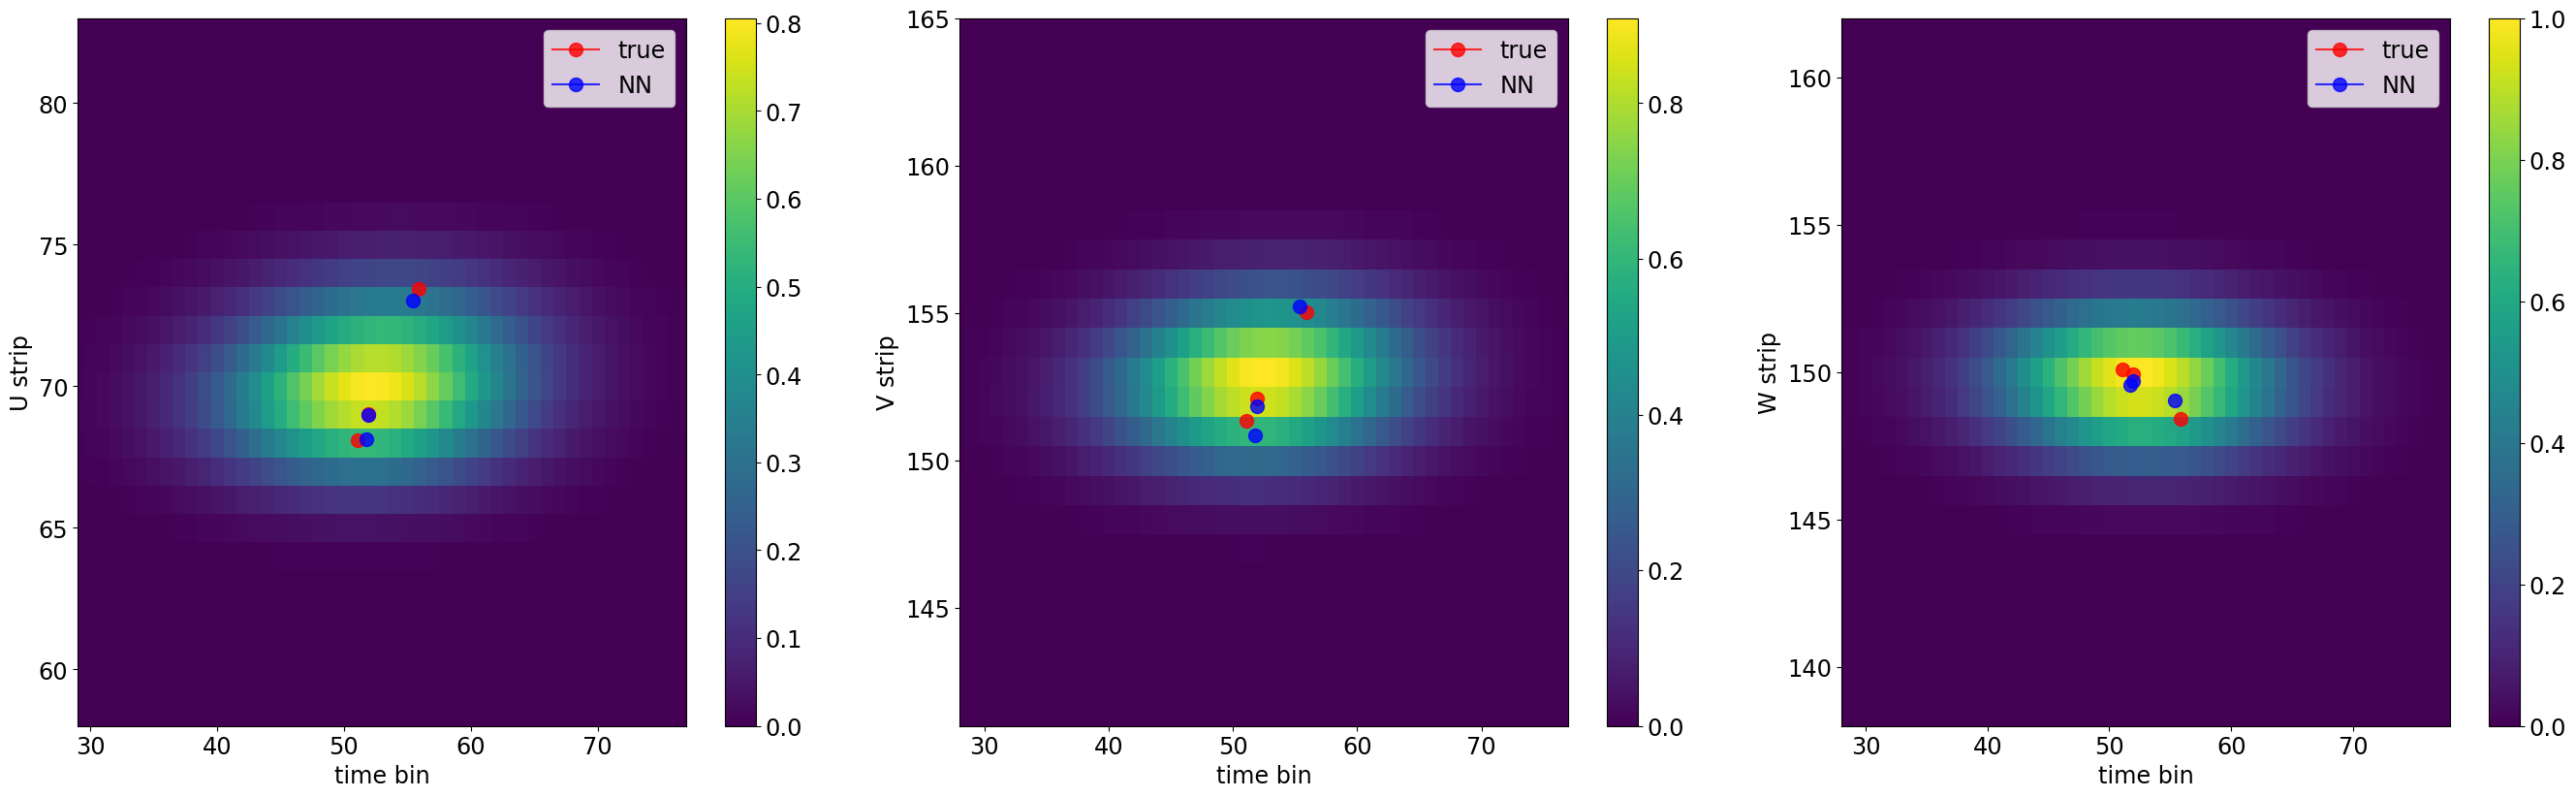

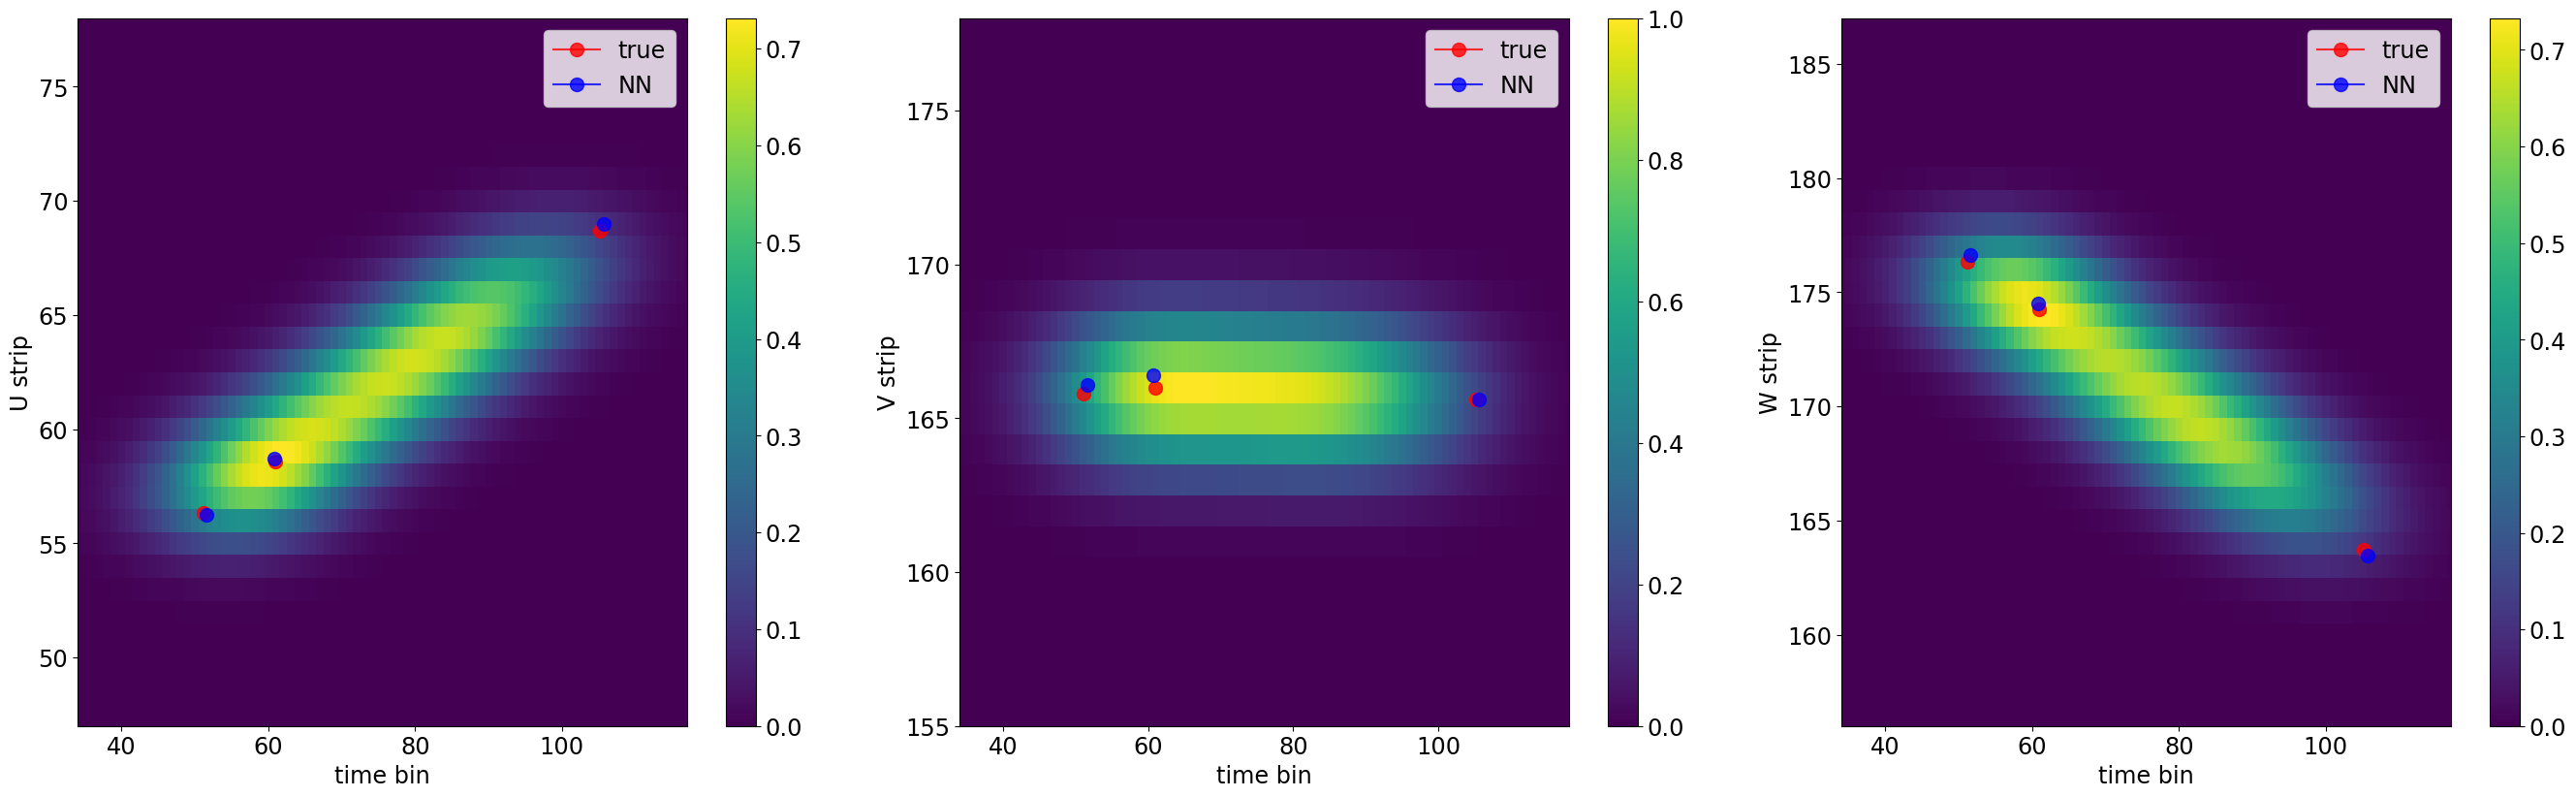

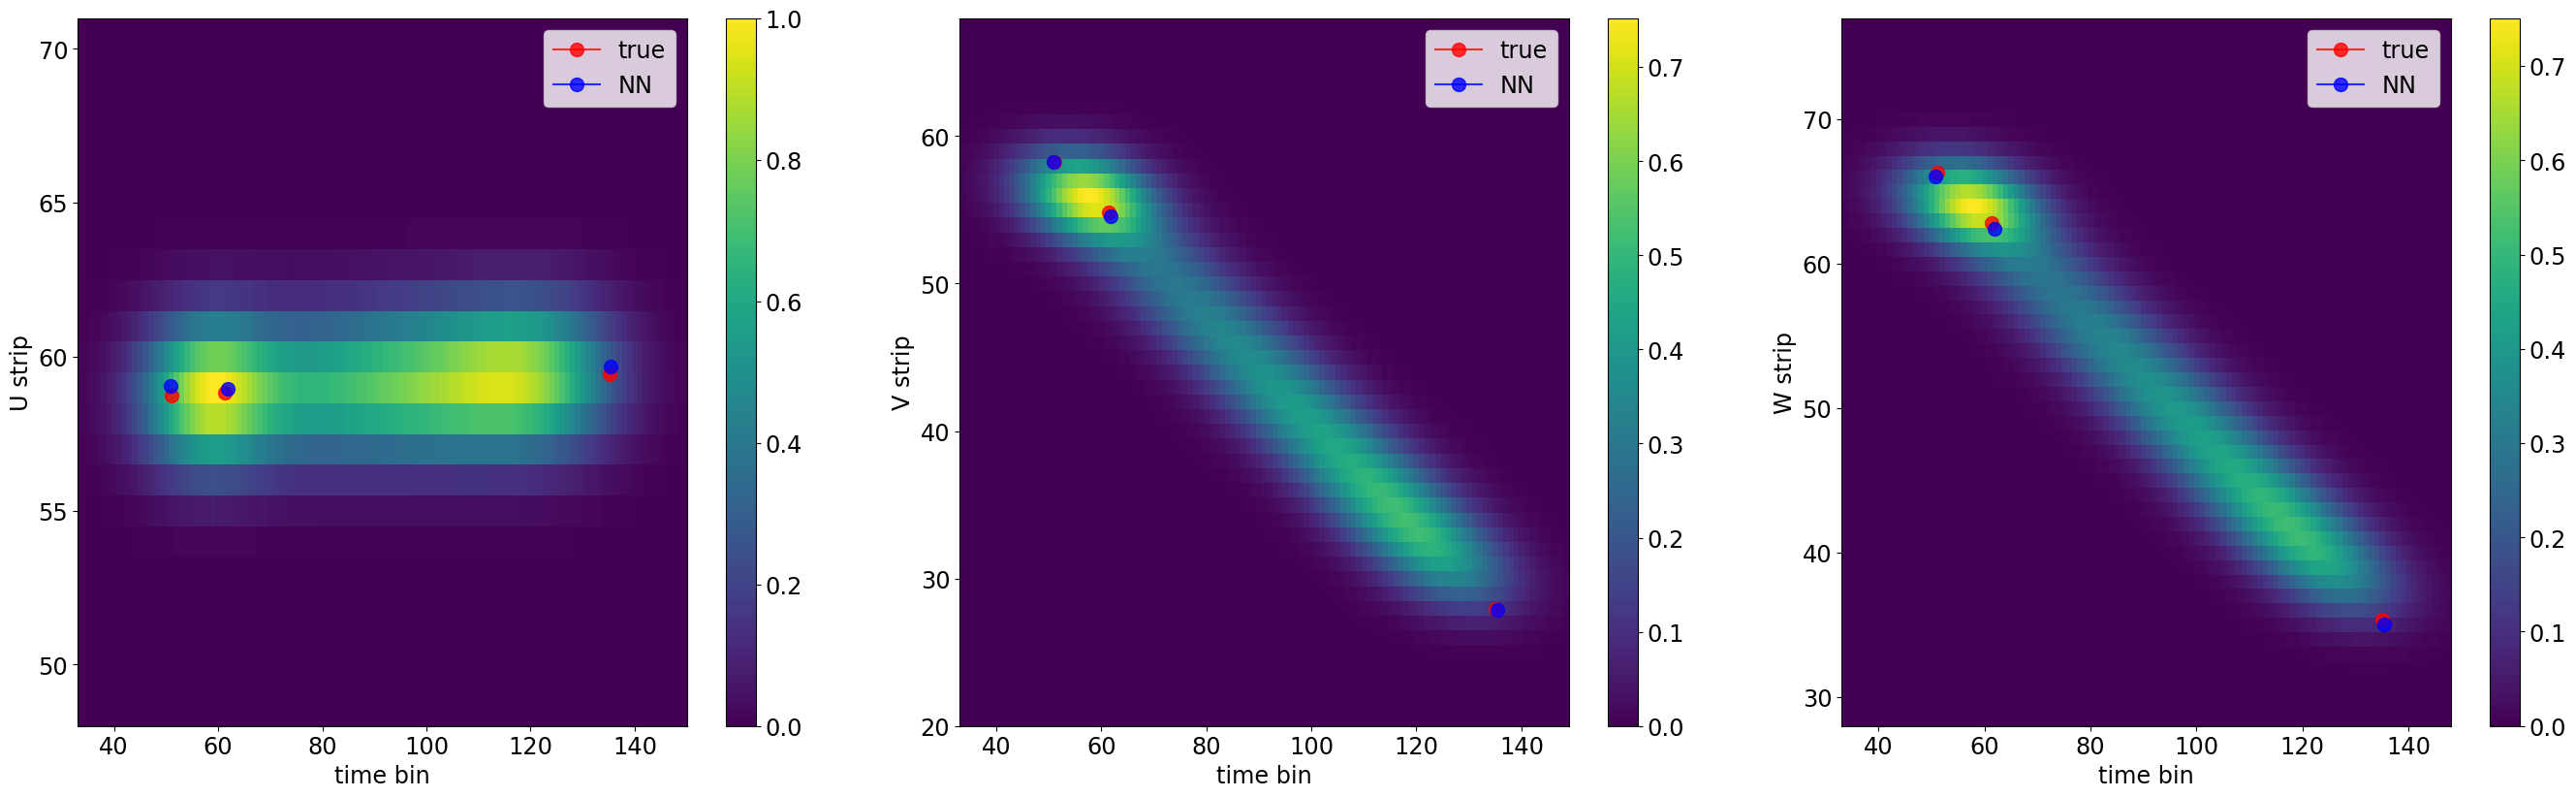

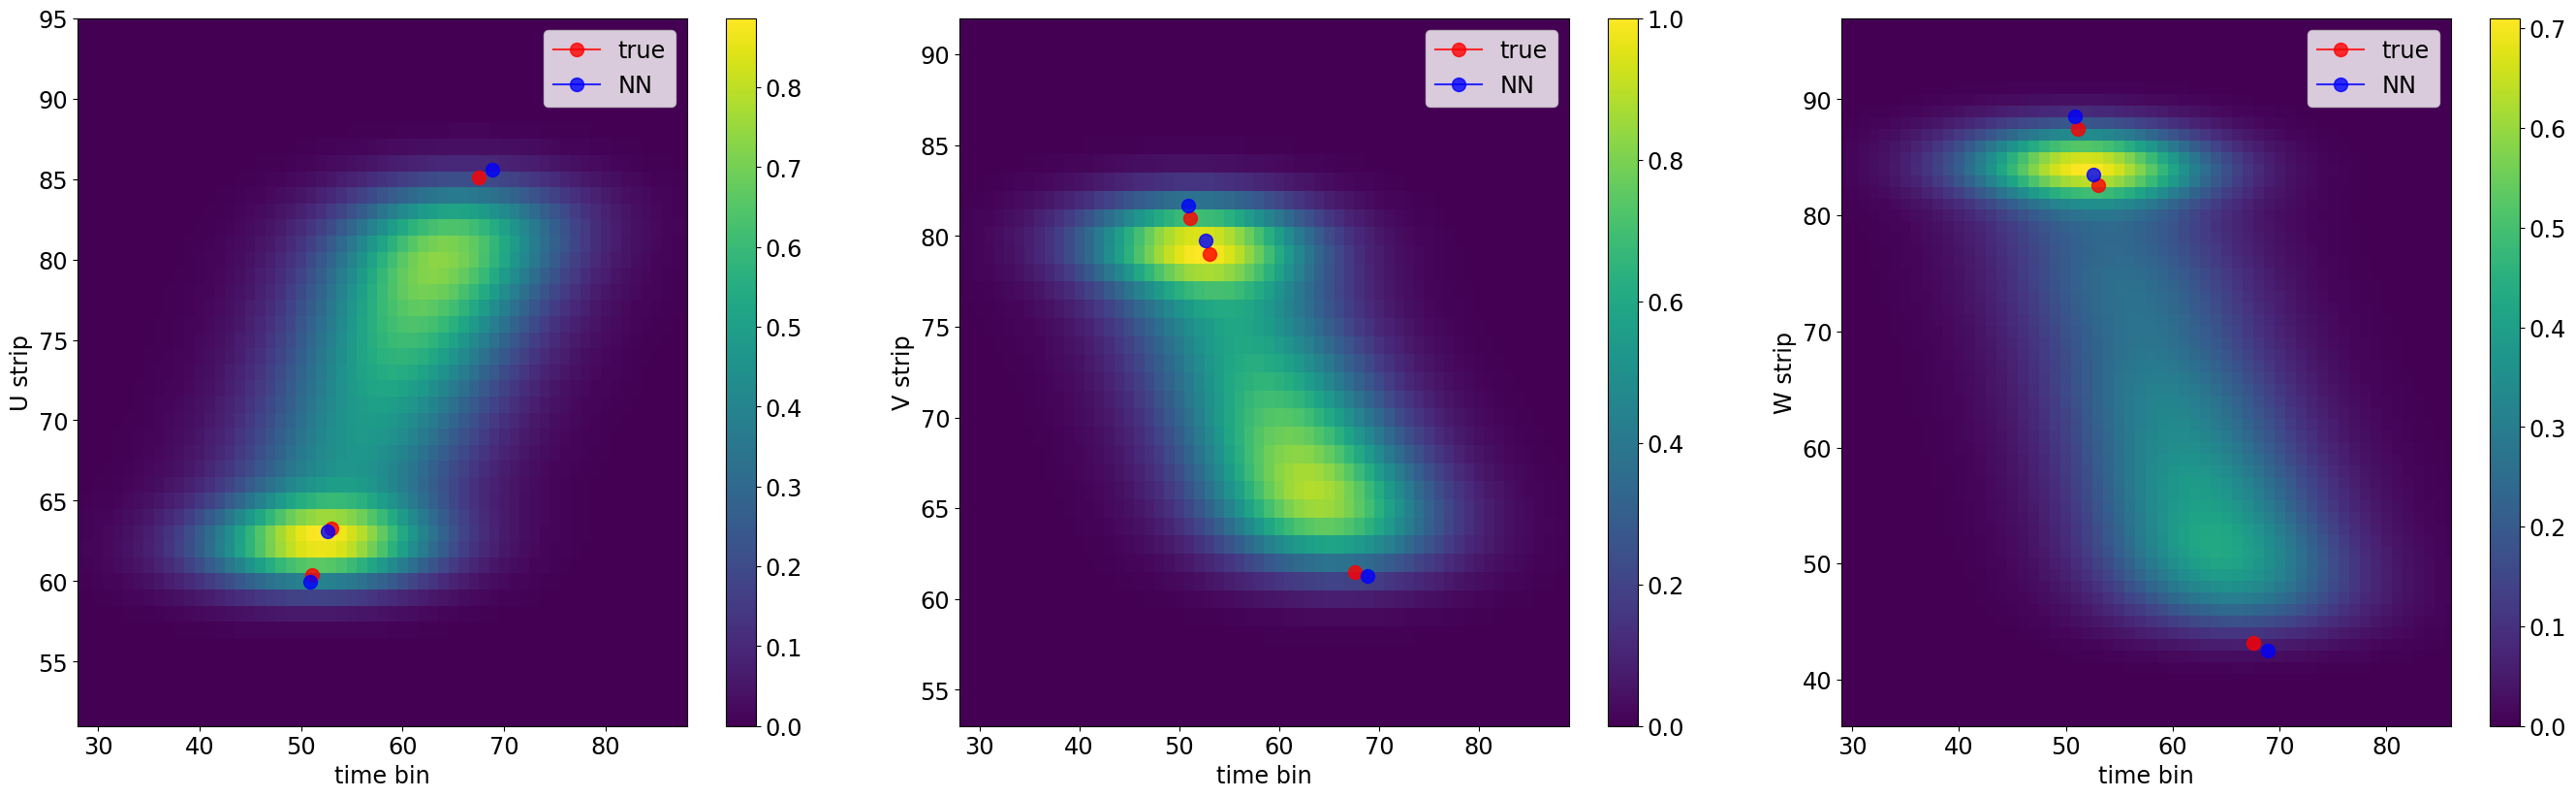

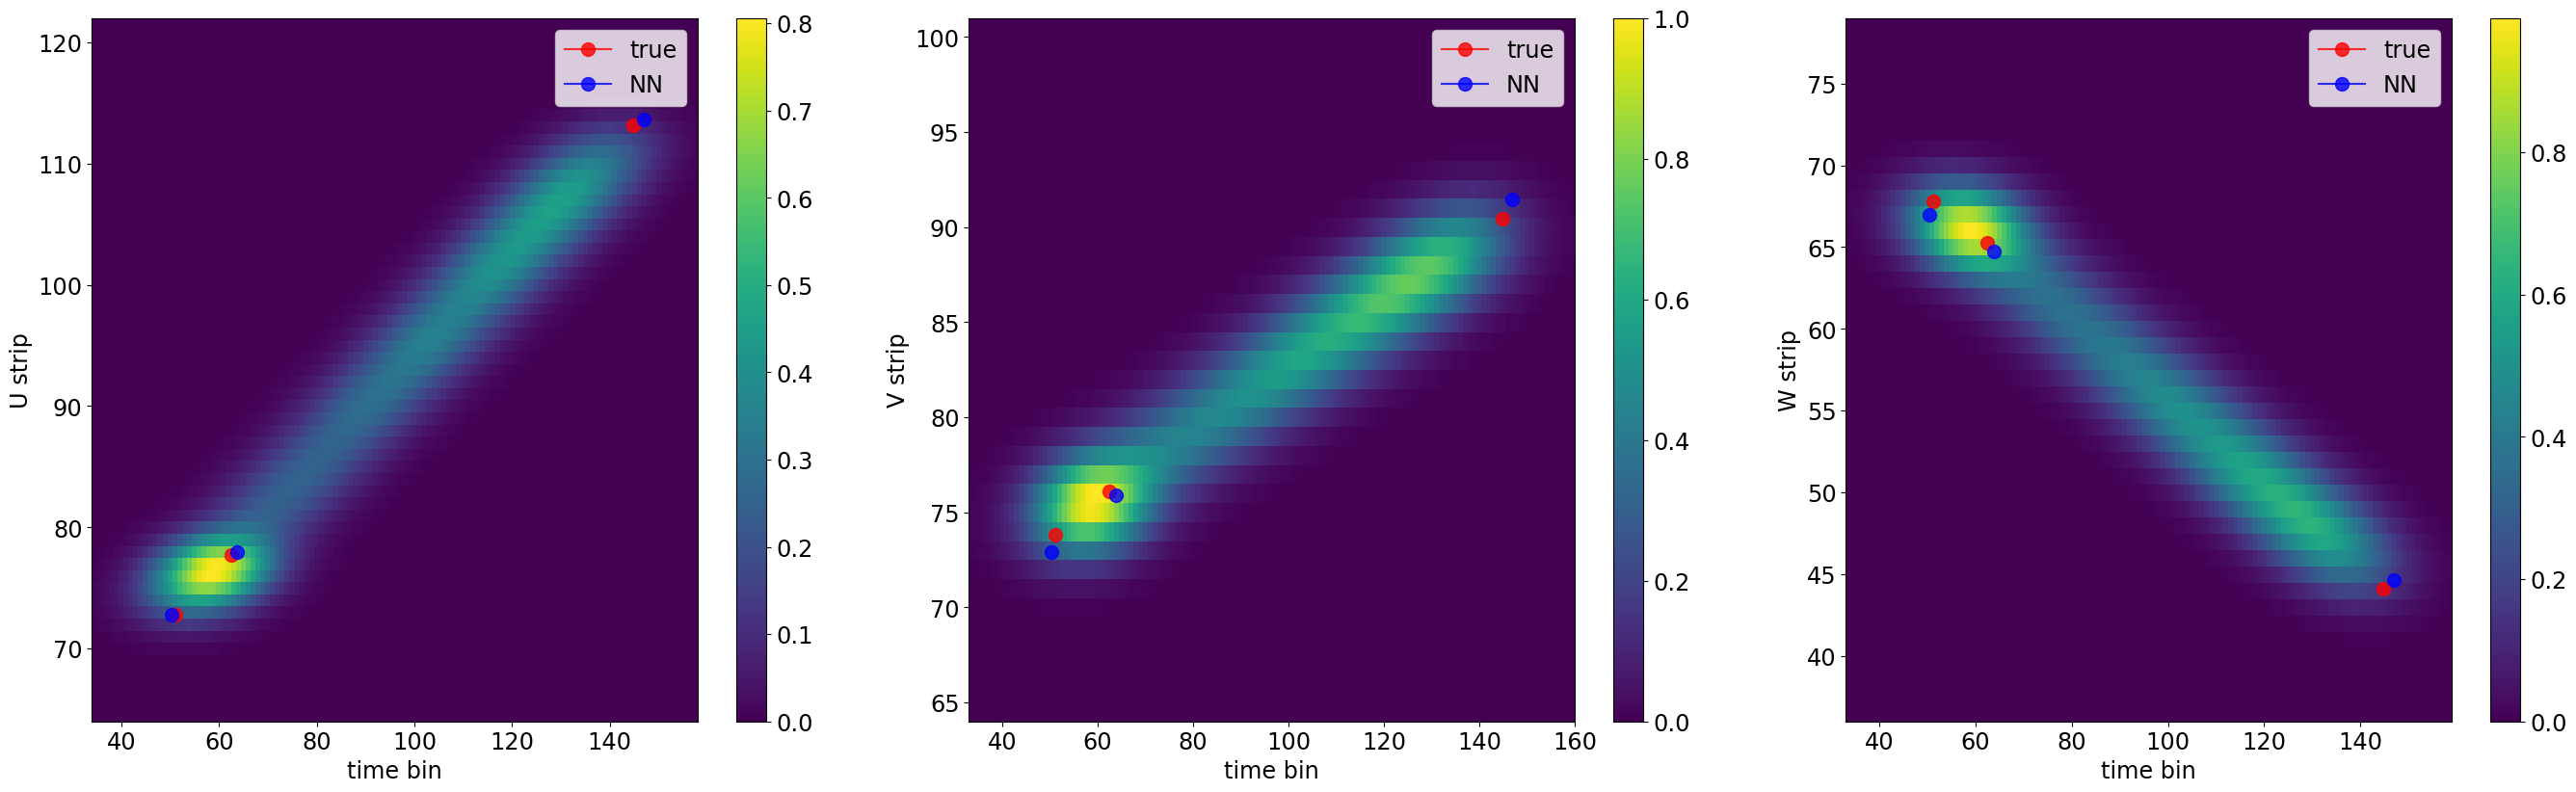

In [41]:
%%time
import utility_functions as utils
importlib.reload(utils)

#model_path = "./training/2023_Apr_28_16_58_32/"
#model_path = "/scratch_hdd/akalinow/ELITPC/PythonAnalysis/training/2023_May_02_23_51_30/"
#model = tf.keras.models.load_model(model_path)

df = utils.df

for aBatch in test_dataset: 
    df = utils.fillPandasDataset(aBatch, df, model)     
    
for aBatch in test_dataset.take(5):
    plf.plotEvent(aBatch, model=model)

df.describe()    

### Resolution plots

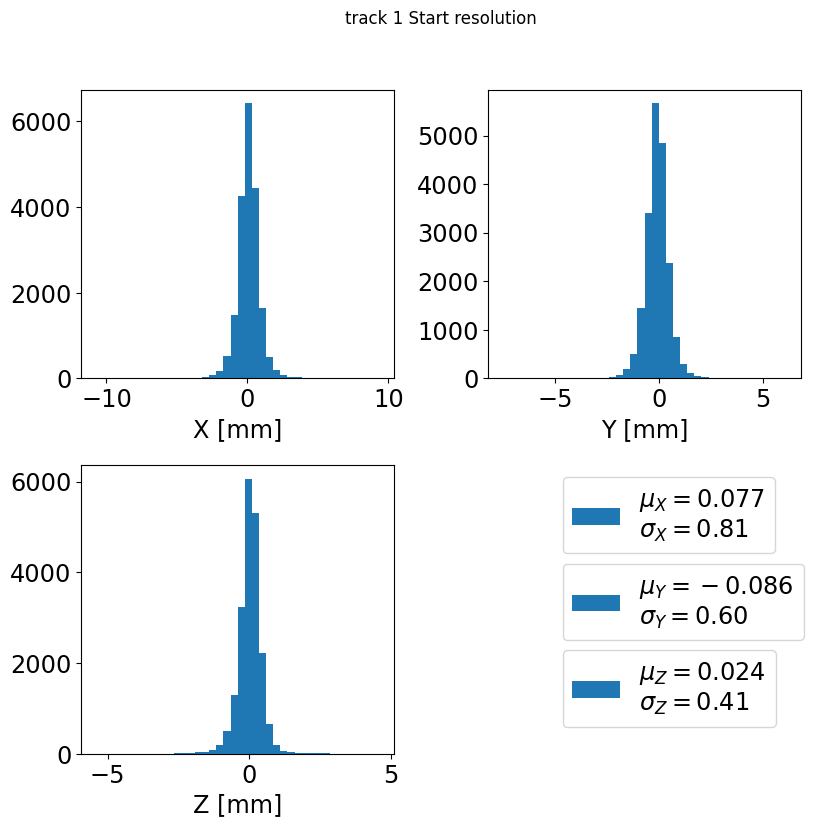

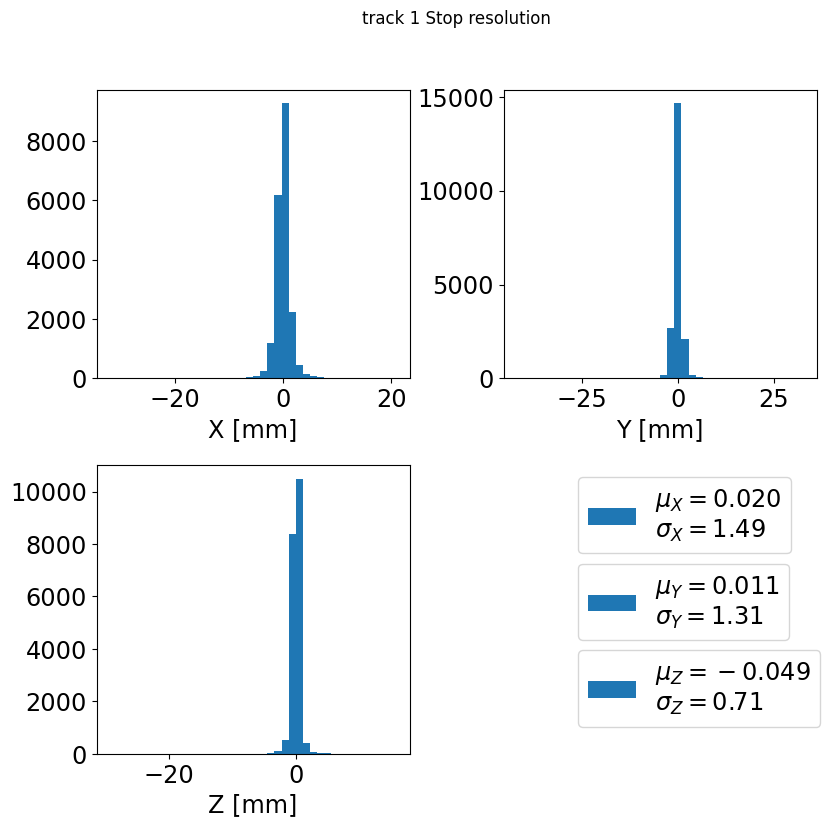

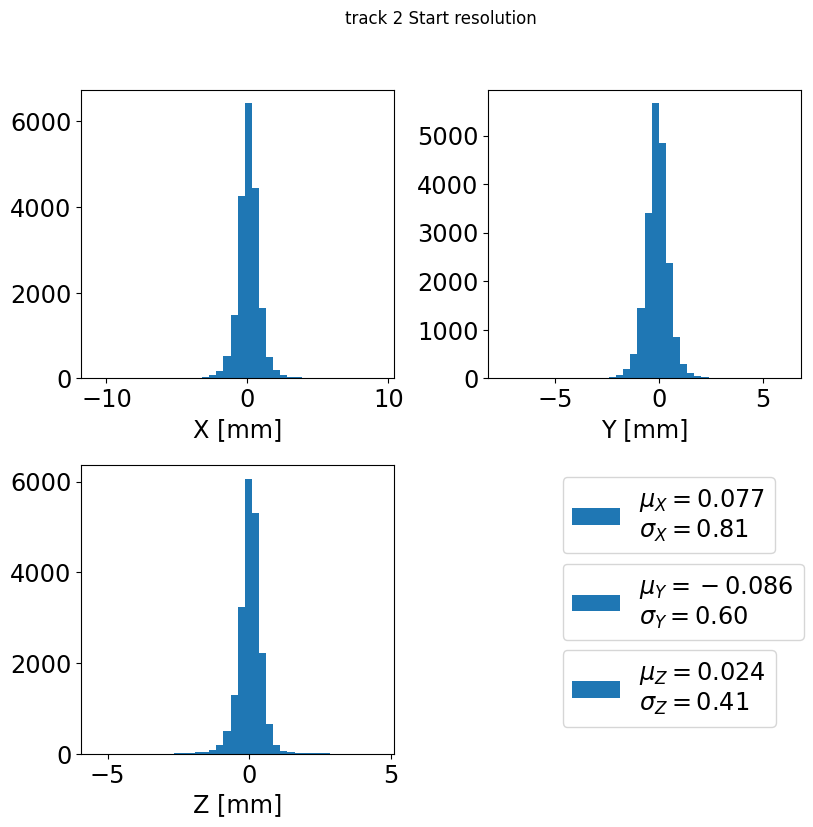

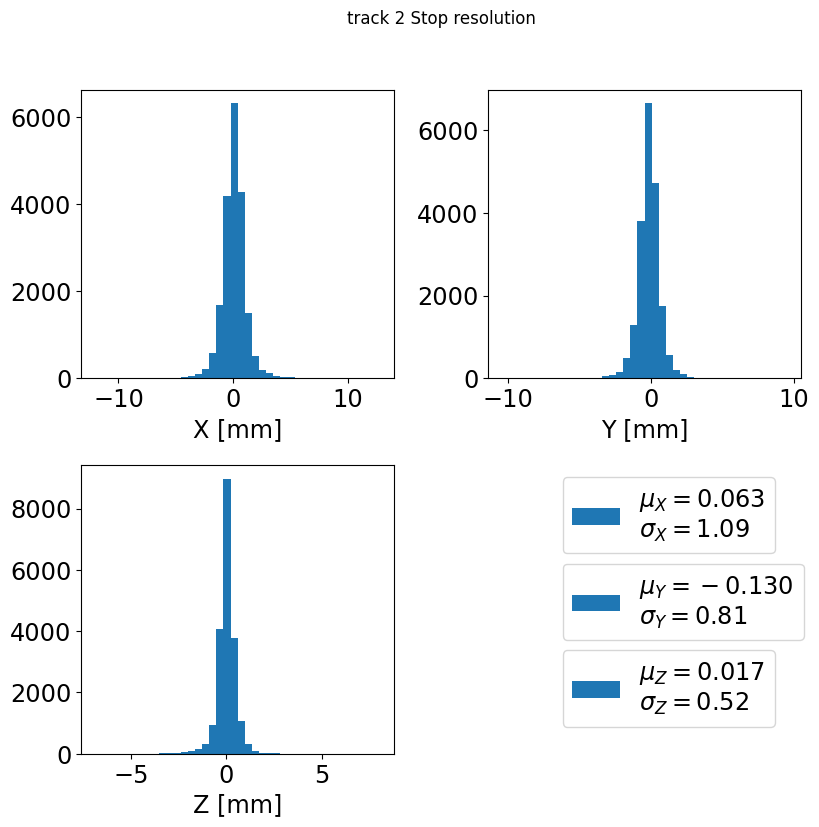

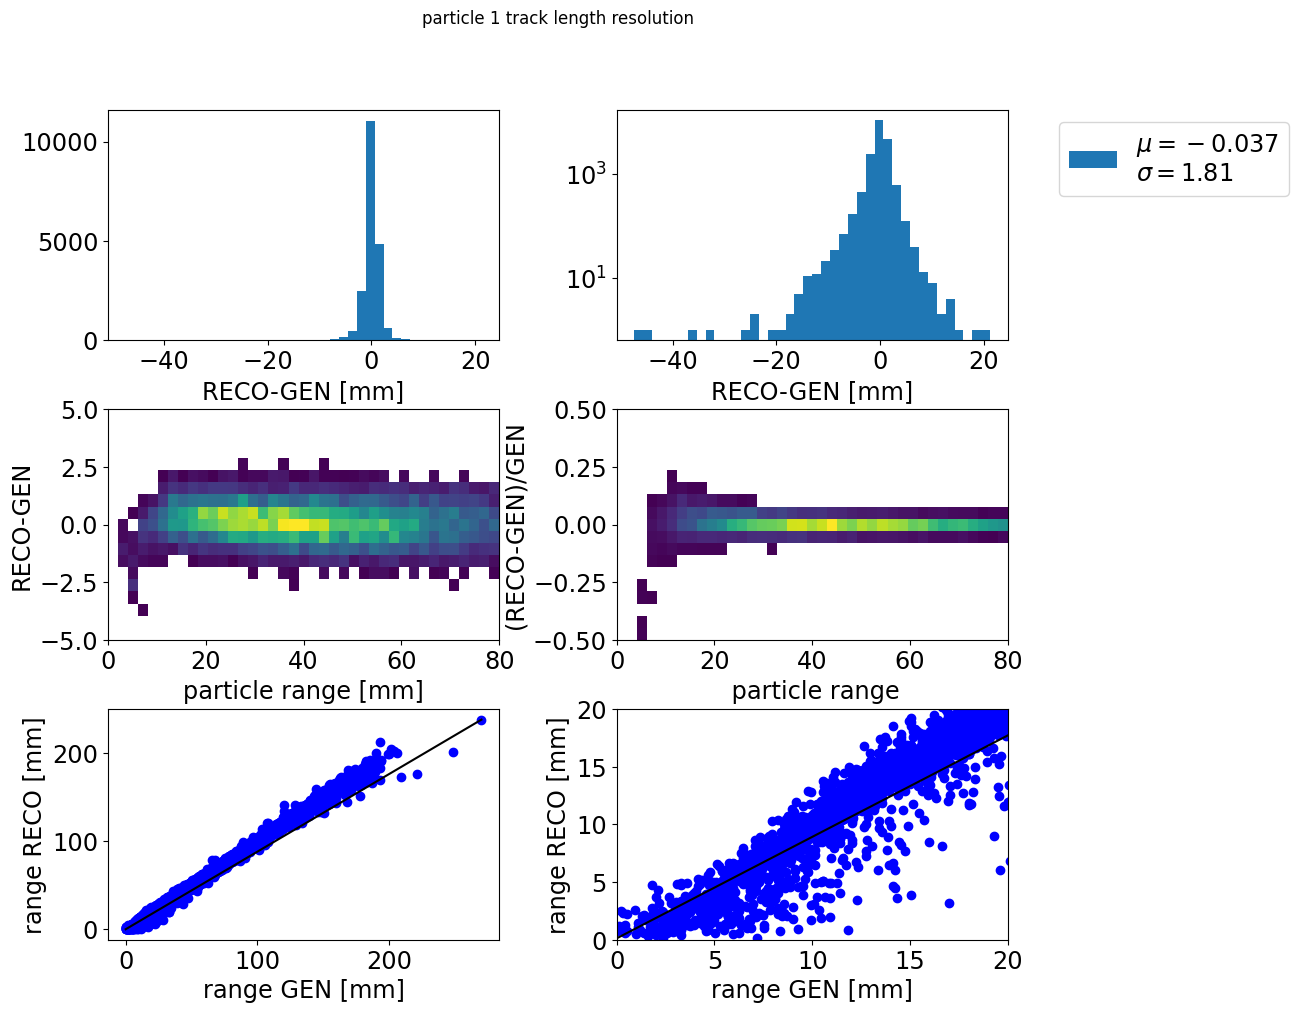

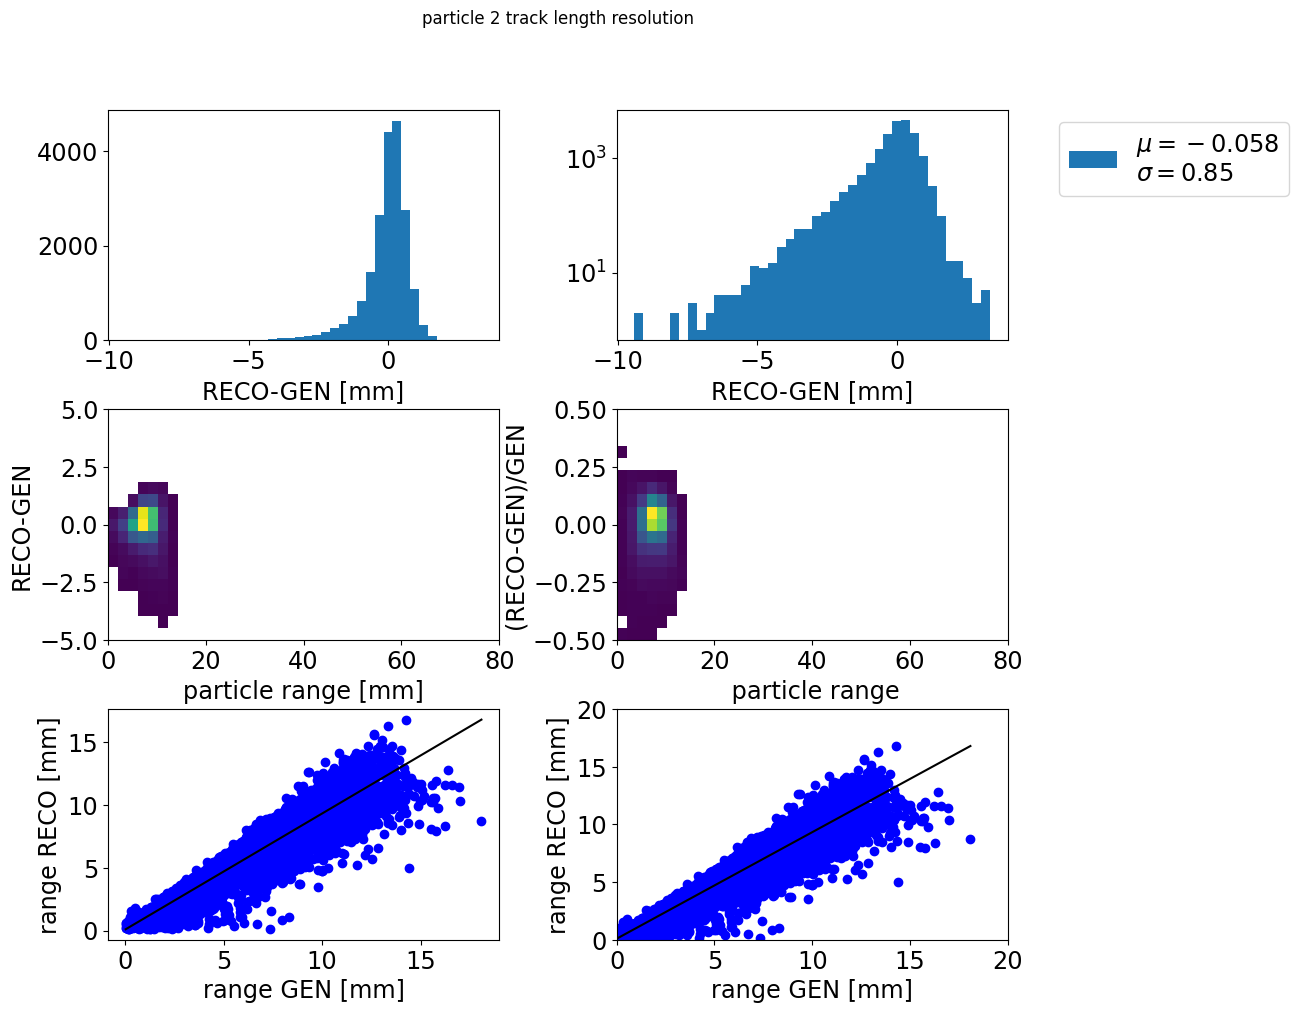

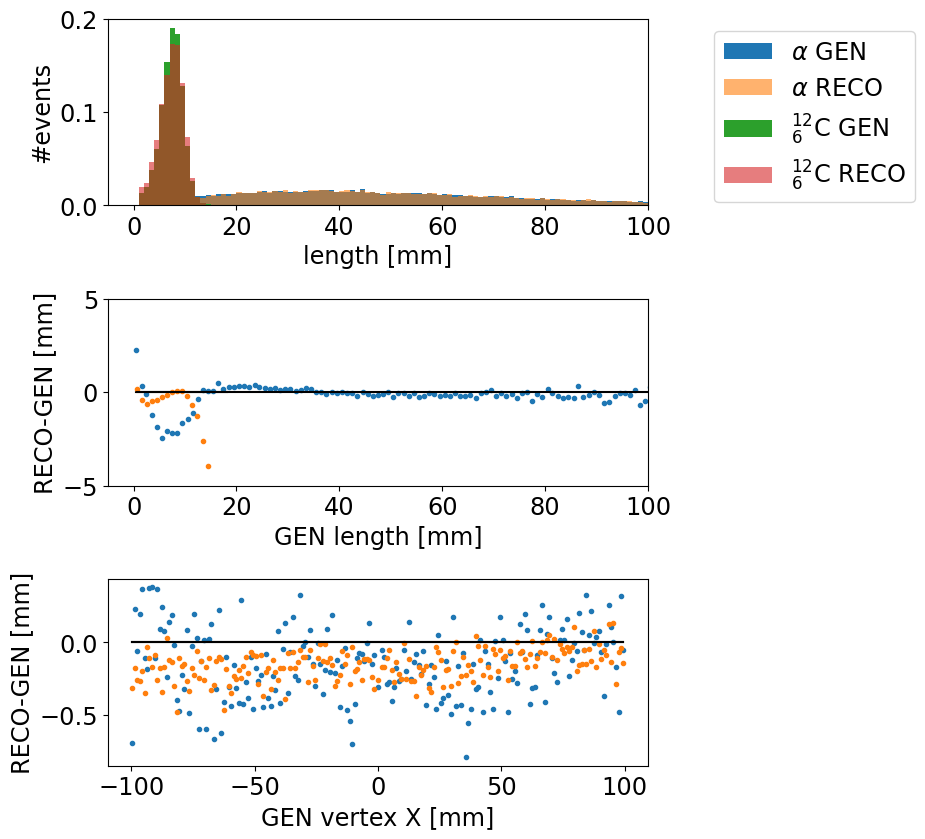

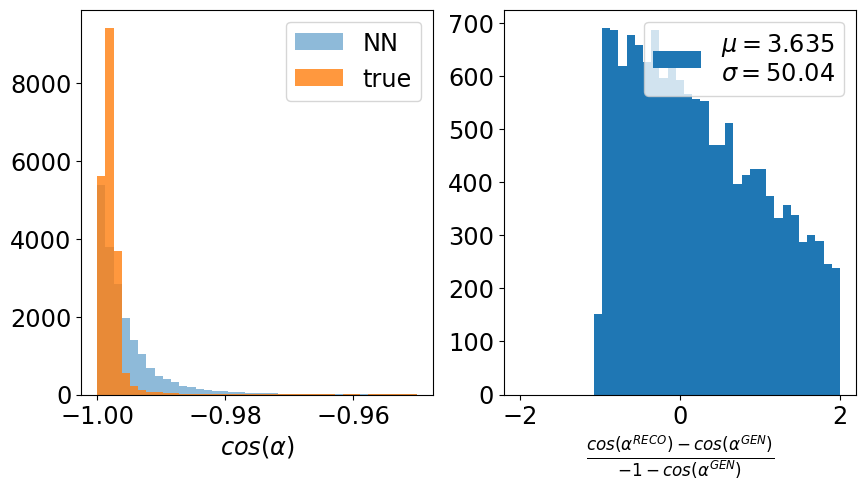

In [45]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df, edge="Start", partIdx=1)
plf.plotEndPointRes(df=df, edge="Stop", partIdx=1)

plf.plotEndPointRes(df=df, edge="Start", partIdx=2)
plf.plotEndPointRes(df=df, edge="Stop", partIdx=2)

plf.plotLengthPull(df, partIdx=1)
plf.plotLengthPull(df, partIdx=2)
plf.plotLengthPullEvolution(df_filtered)
plf.plotOpeningAngleCos(df)

       GEN_StartPosX  GEN_StartPosY  GEN_StartPosZ  GEN_StopPosX_Part1  \
count   19428.000000   19428.000000   19428.000000        19428.000000   
mean        0.797629      -0.111648     -52.294441           -0.449182   
std        57.329723       9.946918      18.194527           68.382950   
min       -99.999596     -19.960903     -66.385445         -232.164764   
25%       -48.461567      -8.172356     -63.609504          -51.712012   
50%         1.448419      -0.175027     -60.416712            0.097169   
75%        49.971529       7.912123     -47.541278           51.090844   
max        99.948830      19.981714      46.866379          231.657928   

       GEN_StopPosY_Part1  GEN_StopPosZ_Part1  GEN_StopPosX_Part2  \
count        19428.000000        19428.000000        19428.000000   
mean             0.166137          -52.006134            0.308756   
std             34.540779           22.470903           57.536224   
min           -180.130692         -150.220657         -10

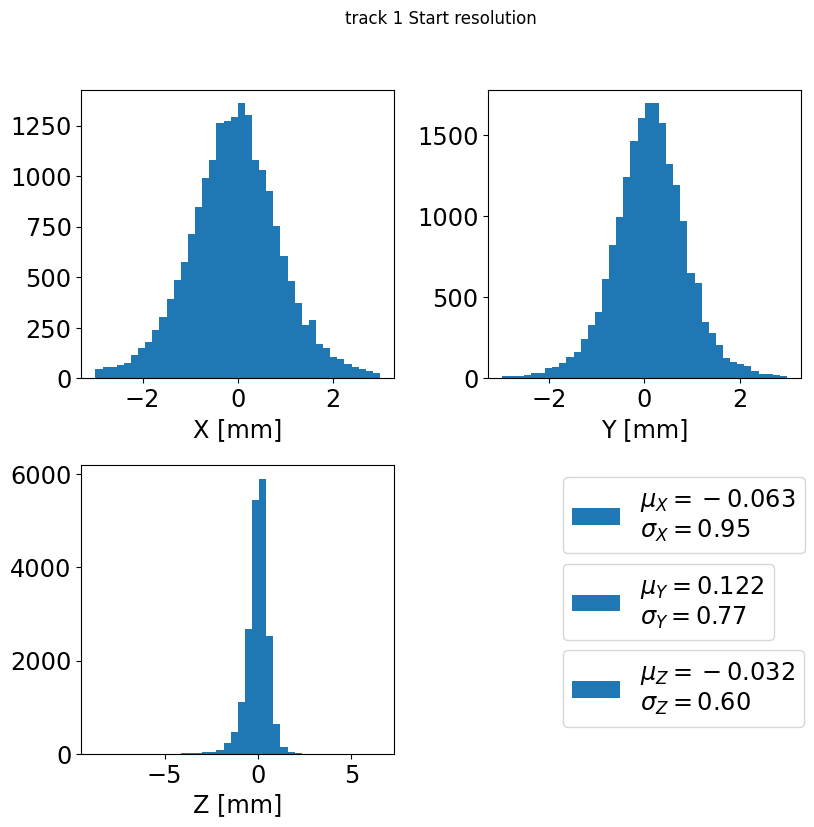

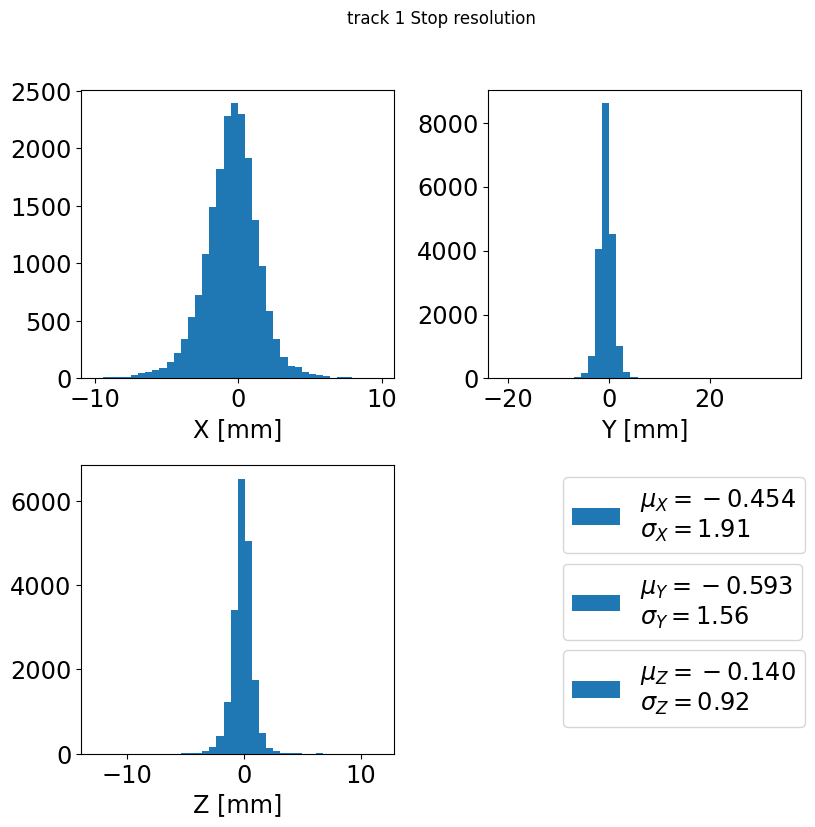

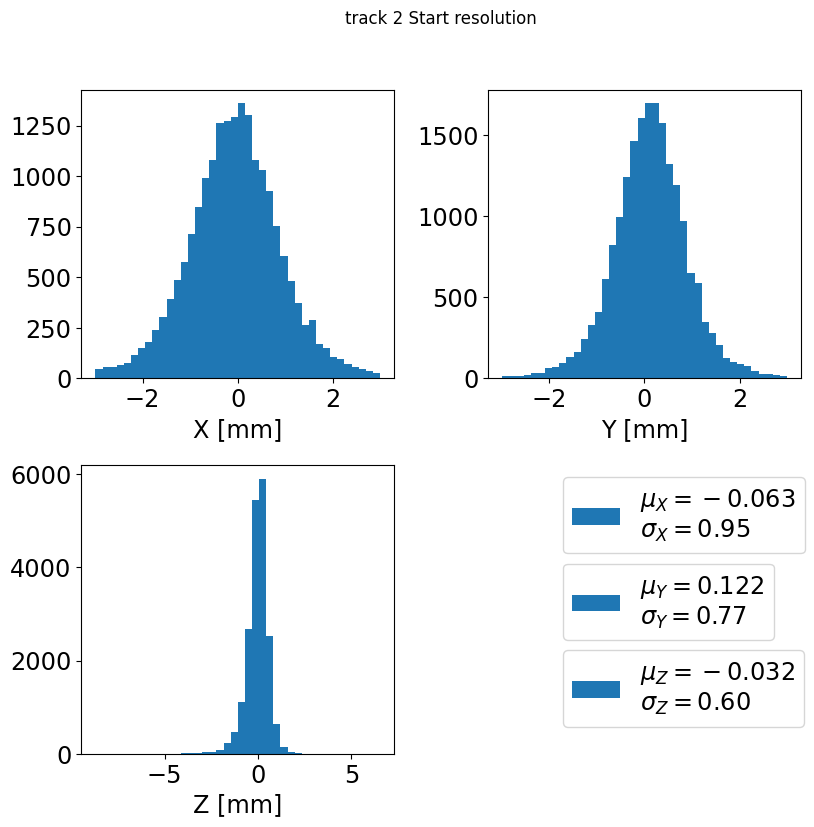

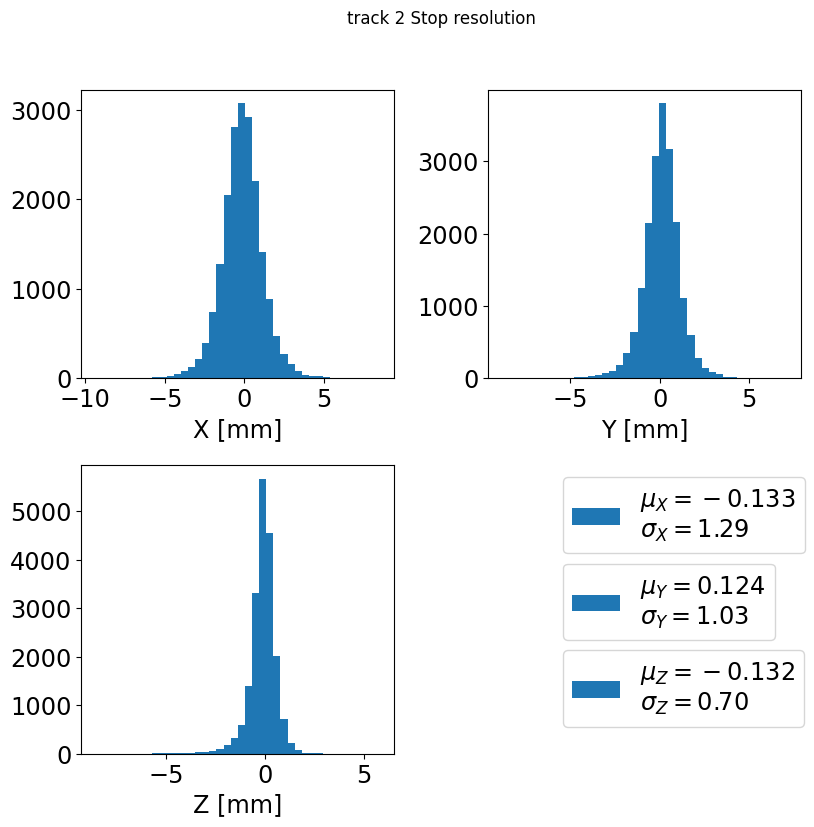

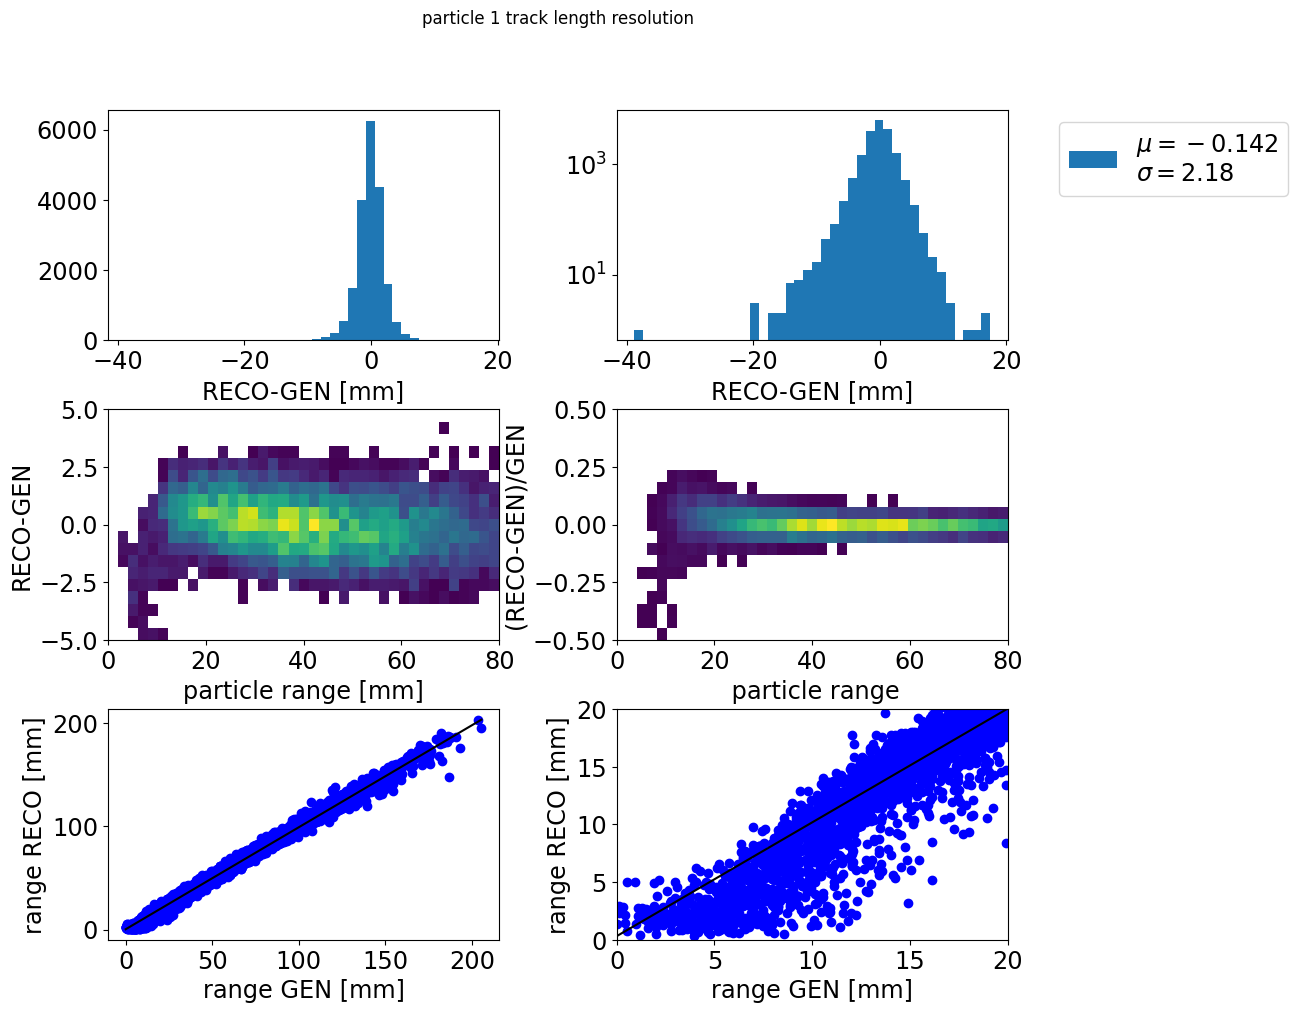

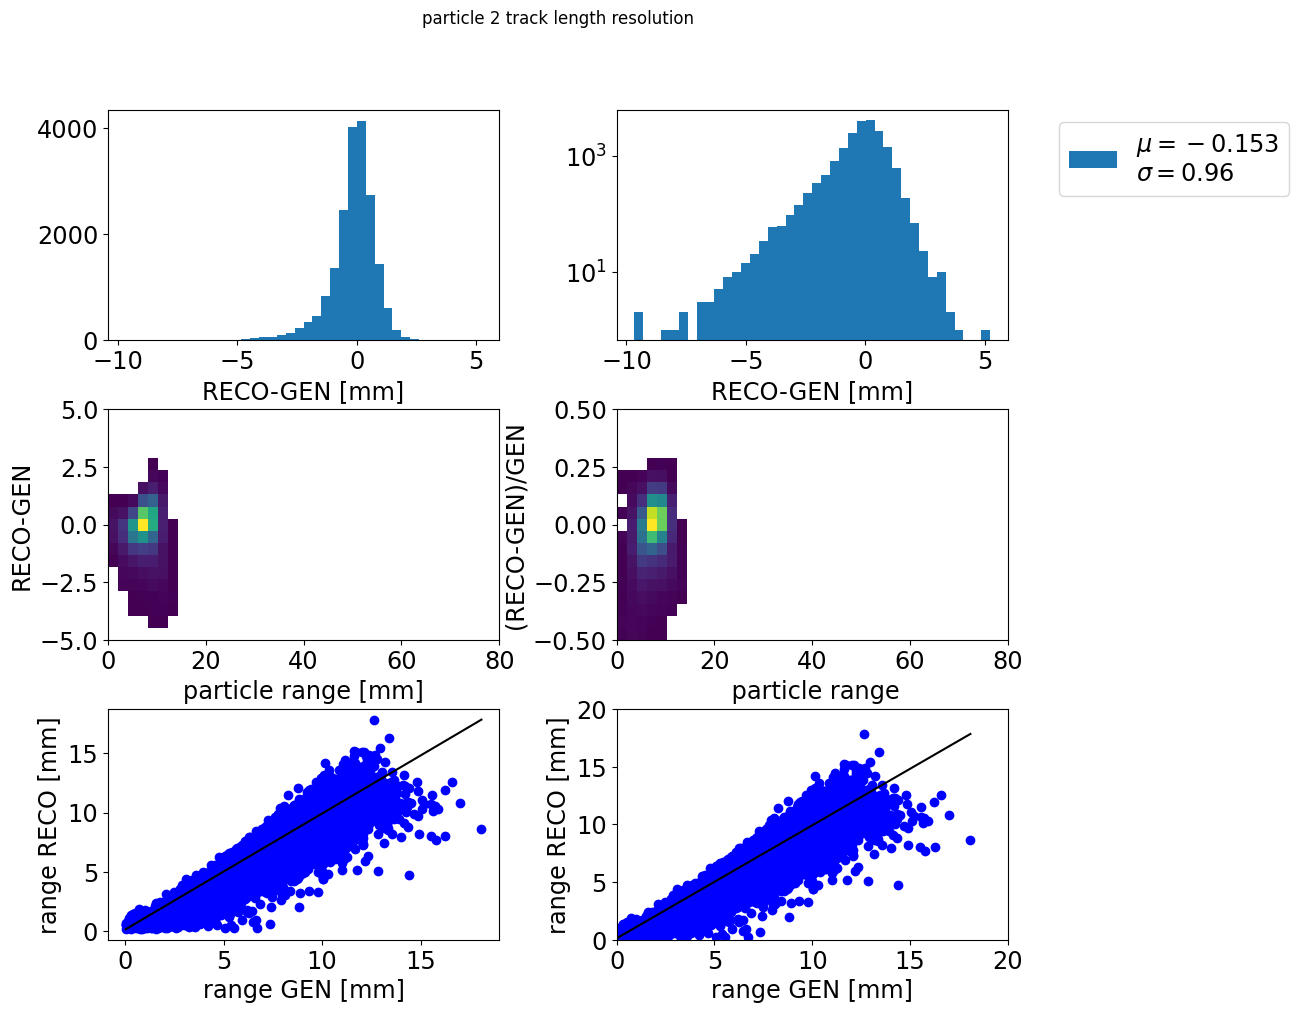

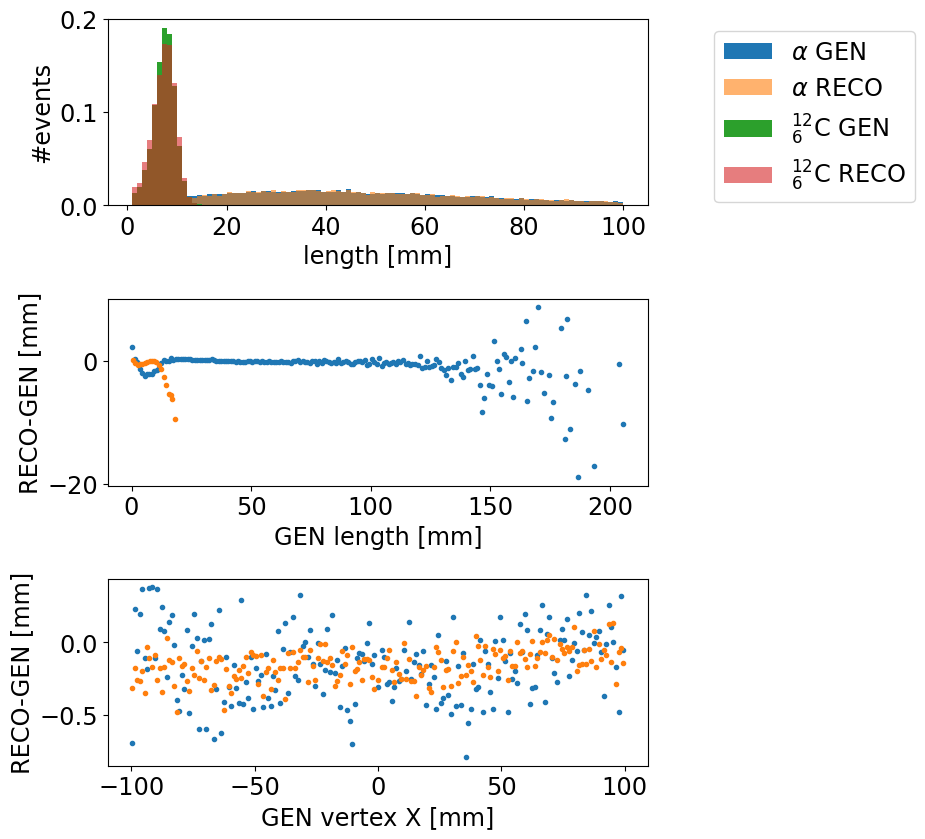

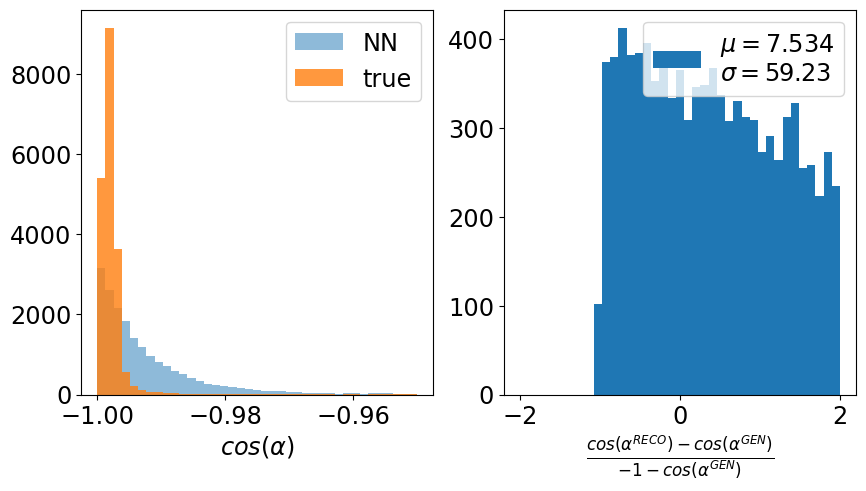

In [39]:
mask = np.abs(df["GEN_StartPosX"] - df["RECO_StartPosX"])<3
df_filtered = df[mask]

mask = np.abs(df_filtered["GEN_StartPosY"] - df_filtered["RECO_StartPosY"])<3
df_filtered = df_filtered[mask]

mask = np.abs(df_filtered["GEN_StopPosX_Part1"] - df_filtered["RECO_StopPosX_Part1"])<10
df_filtered = df_filtered[mask]

print(df_filtered.describe())

plf.plotEndPointRes(df=df_filtered, edge="Start", partIdx=1)
plf.plotEndPointRes(df=df_filtered, edge="Stop", partIdx=1)

plf.plotEndPointRes(df=df_filtered, edge="Start", partIdx=2)
plf.plotEndPointRes(df=df_filtered, edge="Stop", partIdx=2)

plf.plotLengthPull(df_filtered, partIdx=1)
plf.plotLengthPull(df_filtered, partIdx=2)
plf.plotLengthPullEvolution(df_filtered)
plf.plotOpeningAngleCos(df_filtered)

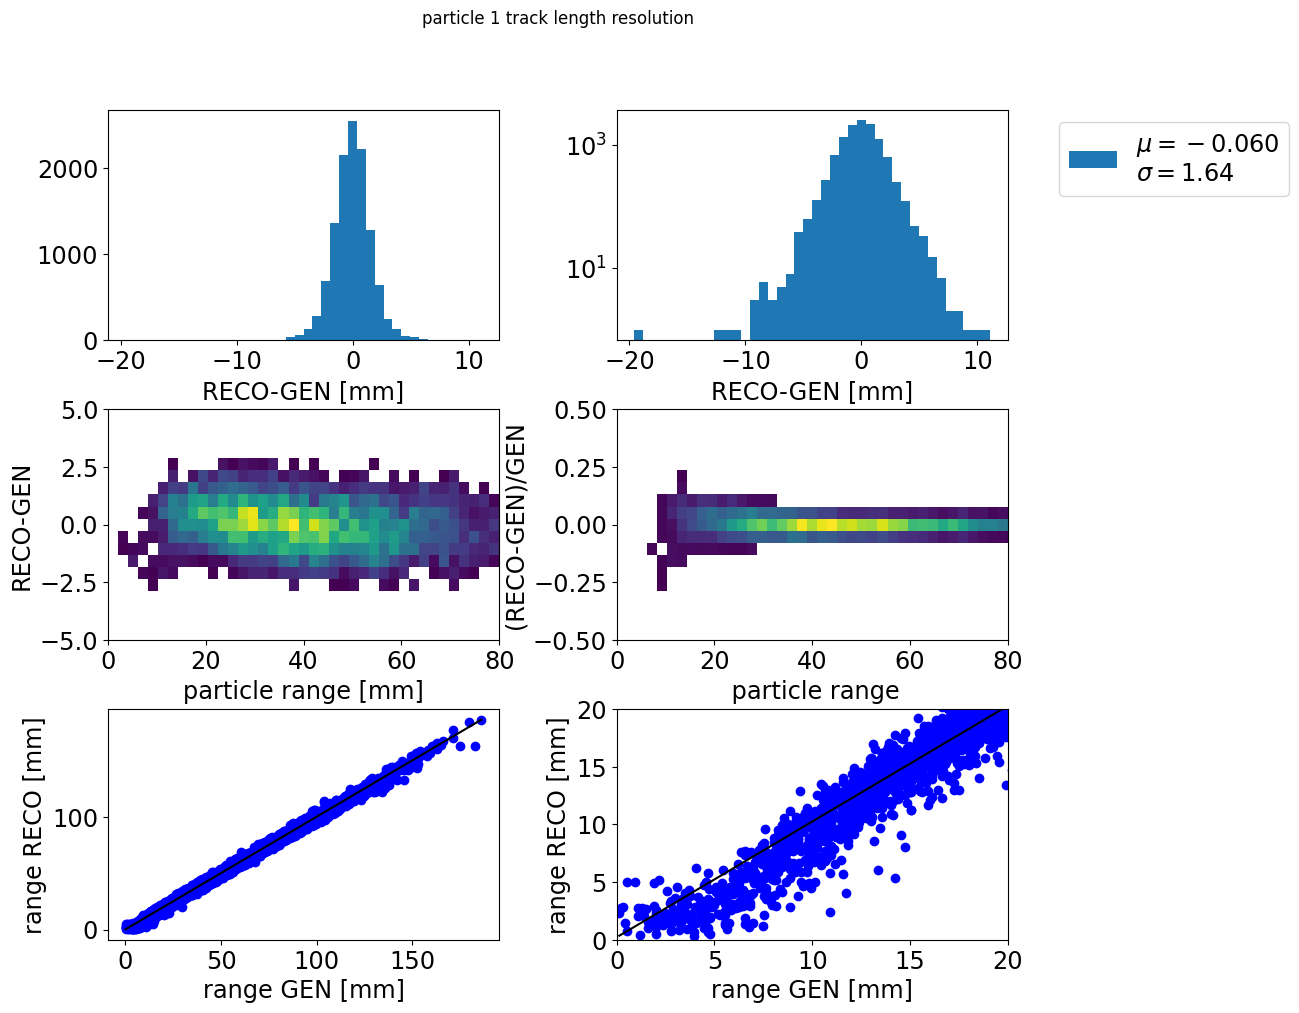

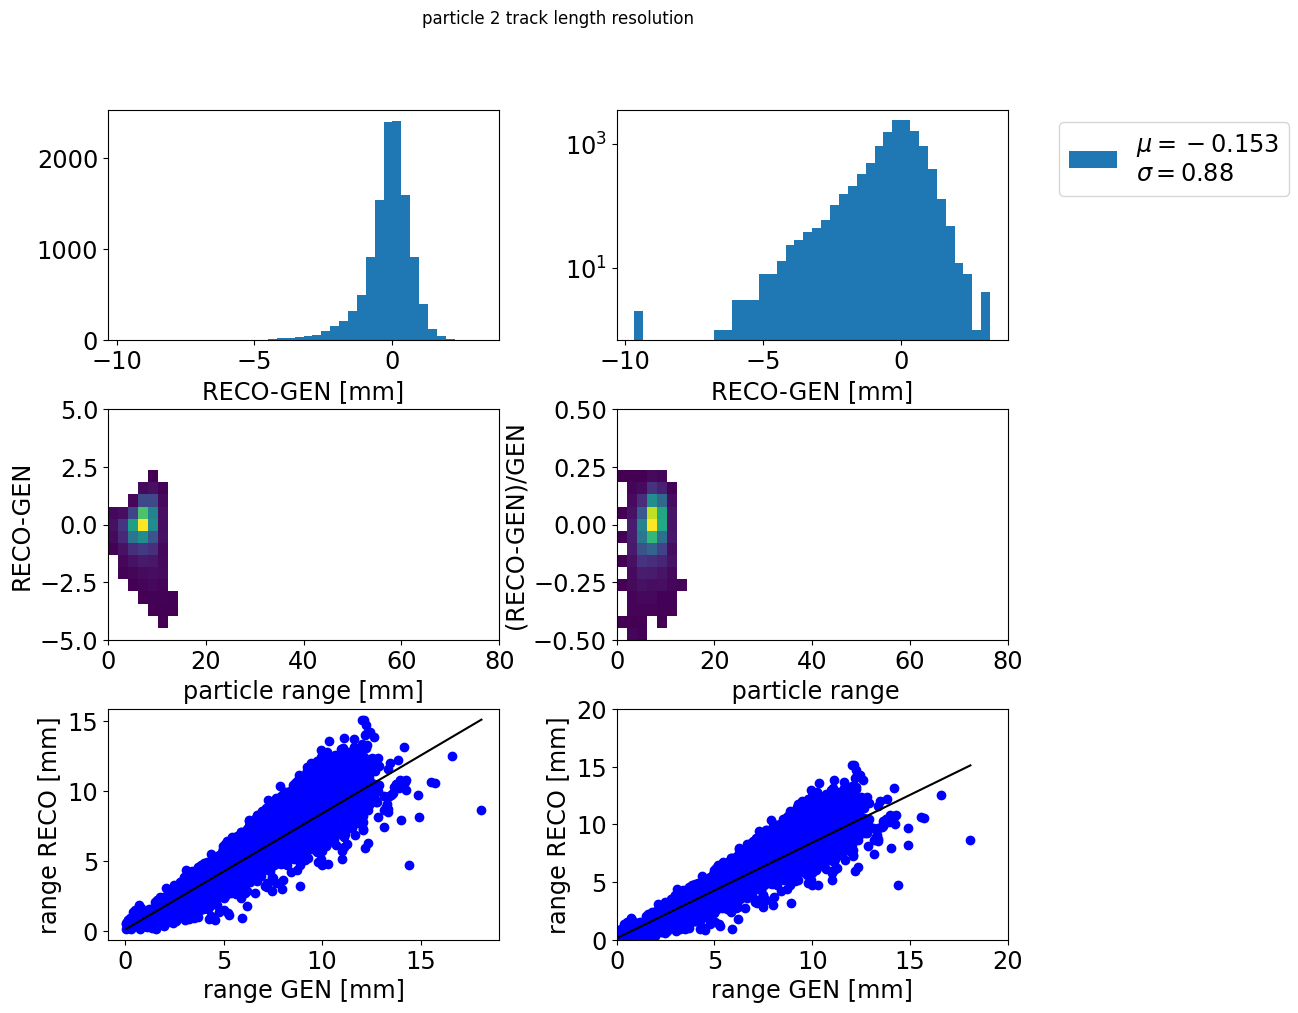

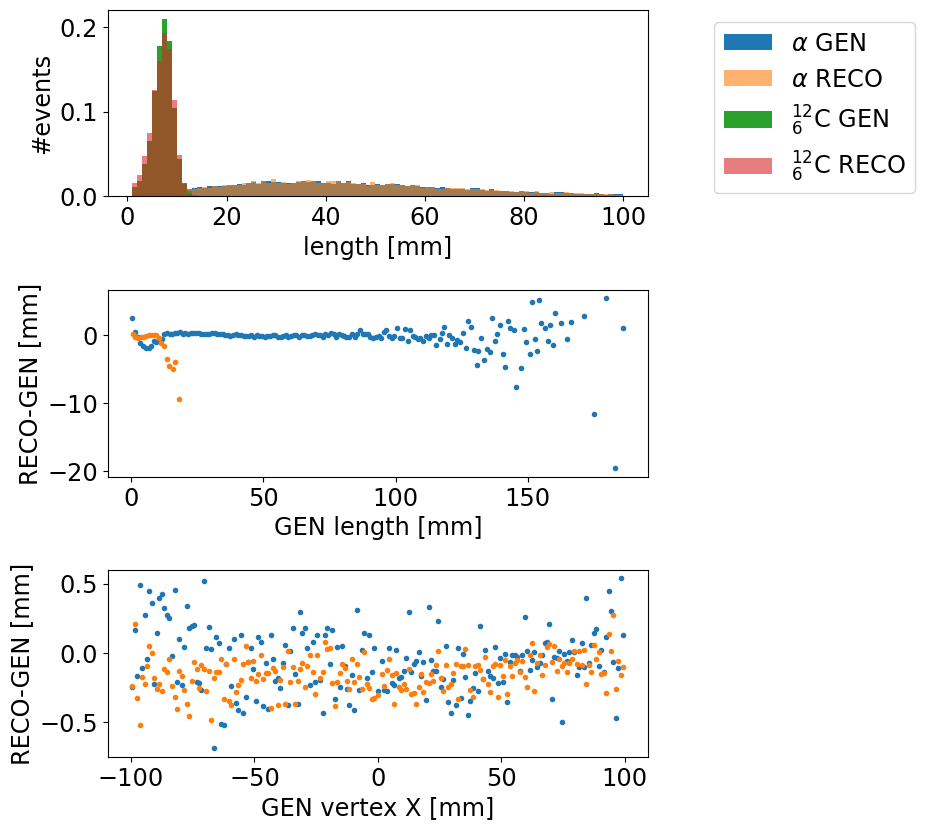

In [33]:
import plotting_functions as plf
importlib.reload(plf)

plf.plotLengthPull(df_filtered, partIdx=1)
plf.plotLengthPull(df_filtered, partIdx=2)
plf.plotLengthPullEvolution(df_filtered)
#plf.plotOpeningAngleCos(df_filtered)